In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
# accounting for different file paths on different systems
path = 'E:/Central Valley Fog/CV_all_rows_wind_temp.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_all_rows_wind_temp.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

           STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0         USM00074917   35.1170  -119.3000  1941-12-01 00:00:00         SAO   
1         USM00074917   35.1170  -119.3000  1941-12-01 01:00:00         SAO   
2         USM00074917   35.1170  -119.3000  1941-12-01 02:00:00         SAO   
3         USM00074917   35.1170  -119.3000  1941-12-01 03:00:00         SAO   
4         USM00074917   35.1170  -119.3000  1941-12-01 04:00:00         SAO   
...               ...       ...        ...                  ...         ...   
14495830  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
14495831  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
14495832  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
14495833  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
14495834  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

          HourlyDewPointTemperature  HourlyDryBulbT

In [3]:
# filtering based on precipiation and visibility thresholds
# visibility threshold included to remove rows with missing visibility values (nan/empty rows)
CV_filtered_rows = CV_rows[CV_rows["HourlyVisibility"] < 17.000]

# CV_filtered_rows = CV_rows[CV_rows["HourlyPrecipitation"] < 0.03]

print("CV_filtered_rows:", CV_filtered_rows.shape)

CV_filtered_rows: (10795959, 17)


In [4]:
# Count days measured per year per station
# Define filtered_days_year
filtered_days_year = (
    # Use the filtered rows that include visibility data
    CV_filtered_rows
    # Drop duplicates based on station, year, month, and day to ensure unique days are counted
    .drop_duplicates(subset=['STATION', 'year', 'month', 'day'])
    # Group rows by station and year to count the number of unique days per station-year
    .groupby(['STATION', 'year'], as_index=False)
    # Count the number of unique days for each station-year combination
    .size()
    # Rename the resulting column to 'filtered_days' for clarity
    .rename(columns={'size': 'filtered_days'})
    # Sort the resulting DataFrame by station and year for better readability
    .sort_values(['STATION', 'year'])
)

# Print to check
print(filtered_days_year.head())

          STATION  year  filtered_days
0  BAKERSFIELD AP  1928             97
1  BAKERSFIELD AP  1929            270
2  BAKERSFIELD AP  1930             97
3  BAKERSFIELD AP  1931            255
4  BAKERSFIELD AP  1932            366


In [5]:
# Find stations with data back to at least 1975
stations_pre1975 = (
    # Group the original CV_rows DataFrame by station and find the minimum year for each station
    CV_rows.groupby('STATION')['year']
    .min()
    # Filter the stations to include only those with a minimum year less than or equal to 1975
    .loc[lambda s: s <= 1975]
    # use .index to get station names
    .index
    # Convert the index to a list
    .tolist()
)
# Print the number of stations and their names
print(len(stations_pre1975), "stations with data back to at least 1975")
print(stations_pre1975)

# make dateframe with station locations
station_locations = (
    # Use the CV_rows dataframe to filter for stations that have data back to at least 1975
    CV_rows[CV_rows['STATION'].isin(stations_pre1975)]
    # Drop duplicate rows based on stations so that each station is considered only once
    .drop_duplicates(subset=['STATION'])
    # Select only the relevant columns for station locations: STATION, LATITUDE, and LONGITUDE
    .loc[:, ['STATION', 'LATITUDE', 'LONGITUDE']]
    # Reset the index of the resulting DataFrame to have a clean, sequential index
    .reset_index(drop=True)
)

26 stations with data back to at least 1975
['BAKERSFIELD AP', 'BEALE AFB', 'CASTLE AFB', 'CHICO ARMY FLYING SCHOOL', 'FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL', 'GARDNER AAF', 'HAMMER AAF', 'LEMOORE REEVES NAS', 'LIVERMORE MUNICIPAL AP', 'LIVERMORE NAS', 'MARYSVILLE AIRPORT (ASOS)', 'MODESTO AP', 'RED BLUFF MUNI AP', 'REDDING AP', 'SACRAMENTO 5 ESE', 'SACRAMENTO AP ASOS', 'SACRAMENTO MATHER AFB', 'SACRAMENTO MCCLELLAN AFB', 'SACRAMENTO METROPOLITAN AP', 'STOCKTON AP', 'TRAVIS FIELD AFB', 'VERNALIS NAVAL AUX', 'VISALIA MUNICIPAL AP', 'WILLIAMS CAA AIRPORT']


In [6]:
# Monthly data coverage (%) by station-year-month using CV_rows
# Coverage is based on unique hourly timestamps in each month:
# coverage_pct = observed_unique_hours / expected_hours_in_month * 100

# Create cv_cov with station and date columns from CV_rows
cv_cov = CV_rows[["STATION", "DATE"]].copy()
# convert DATE column to datetime format and drop rows with invalid dates
cv_cov["DATE"] = pd.to_datetime(cv_cov["DATE"], errors="coerce")
# drop rows with NaT values in the DATE column to ensure only valid dates are considered
cv_cov = cv_cov.dropna(subset=["DATE"])

# Count unique hours to avoid multiple records within the same hour
# set all minutes and seconds to zero, so that all records within the same hour are treated as one
cv_cov["hour_ts"] = cv_cov["DATE"].dt.floor("h")
# drop duplicates based on station and hour timestamp to ensure unique hourly records are counted
cv_cov = cv_cov.drop_duplicates(subset=["STATION", "hour_ts"])

# Add year and month columns to cv_cov for grouping
cv_cov["year"] = cv_cov["hour_ts"].dt.year
cv_cov["month"] = cv_cov["hour_ts"].dt.month

# Calculate monthly coverage for each station-year-month combination
monthly_coverage = (
    # Group by unique station-year-month
    cv_cov.groupby(["STATION", "year", "month"], as_index=False)
    # count the number of unique hourly timestamps for each station-year-month combination
    .size()
    # Name the resulting column to 'observed_hours'
    .rename(columns={"size": "observed_hours"})
)

# Calculate expected hours in each month and coverage percentage
monthly_coverage["month_start"] = pd.to_datetime(
    # Create a datetime object for the first day of each month using station year and month
    dict(year=monthly_coverage["year"], month=monthly_coverage["month"], day=1)
)
# Calculate the expected number of hours in each month by multiplying the number of days in the month by 24
monthly_coverage["expected_hours"] = monthly_coverage["month_start"].dt.days_in_month * 24
# Calculate the coverage percentage by dividing observed hours by expected hours and multiplying by 100
monthly_coverage["coverage_pct"] = (
    monthly_coverage["observed_hours"] / monthly_coverage["expected_hours"] * 100
)

# Print the first 12 rows of monthly_coverage and the total number of rows
print(monthly_coverage.head(12))
print("Rows:", monthly_coverage.shape[0])

           STATION  year  month  observed_hours month_start  expected_hours  \
0   BAKERSFIELD AP  1928      1              35  1928-01-01             744   
1   BAKERSFIELD AP  1928      9              16  1928-09-01             720   
2   BAKERSFIELD AP  1928     10             206  1928-10-01             744   
3   BAKERSFIELD AP  1928     11             210  1928-11-01             720   
4   BAKERSFIELD AP  1928     12             217  1928-12-01             744   
5   BAKERSFIELD AP  1929      1             200  1929-01-01             744   
6   BAKERSFIELD AP  1929      2             196  1929-02-01             672   
7   BAKERSFIELD AP  1929      3             217  1929-03-01             744   
8   BAKERSFIELD AP  1929      4             210  1929-04-01             720   
9   BAKERSFIELD AP  1929      5             217  1929-05-01             744   
10  BAKERSFIELD AP  1929      6             210  1929-06-01             720   
11  BAKERSFIELD AP  1929      7             431  192

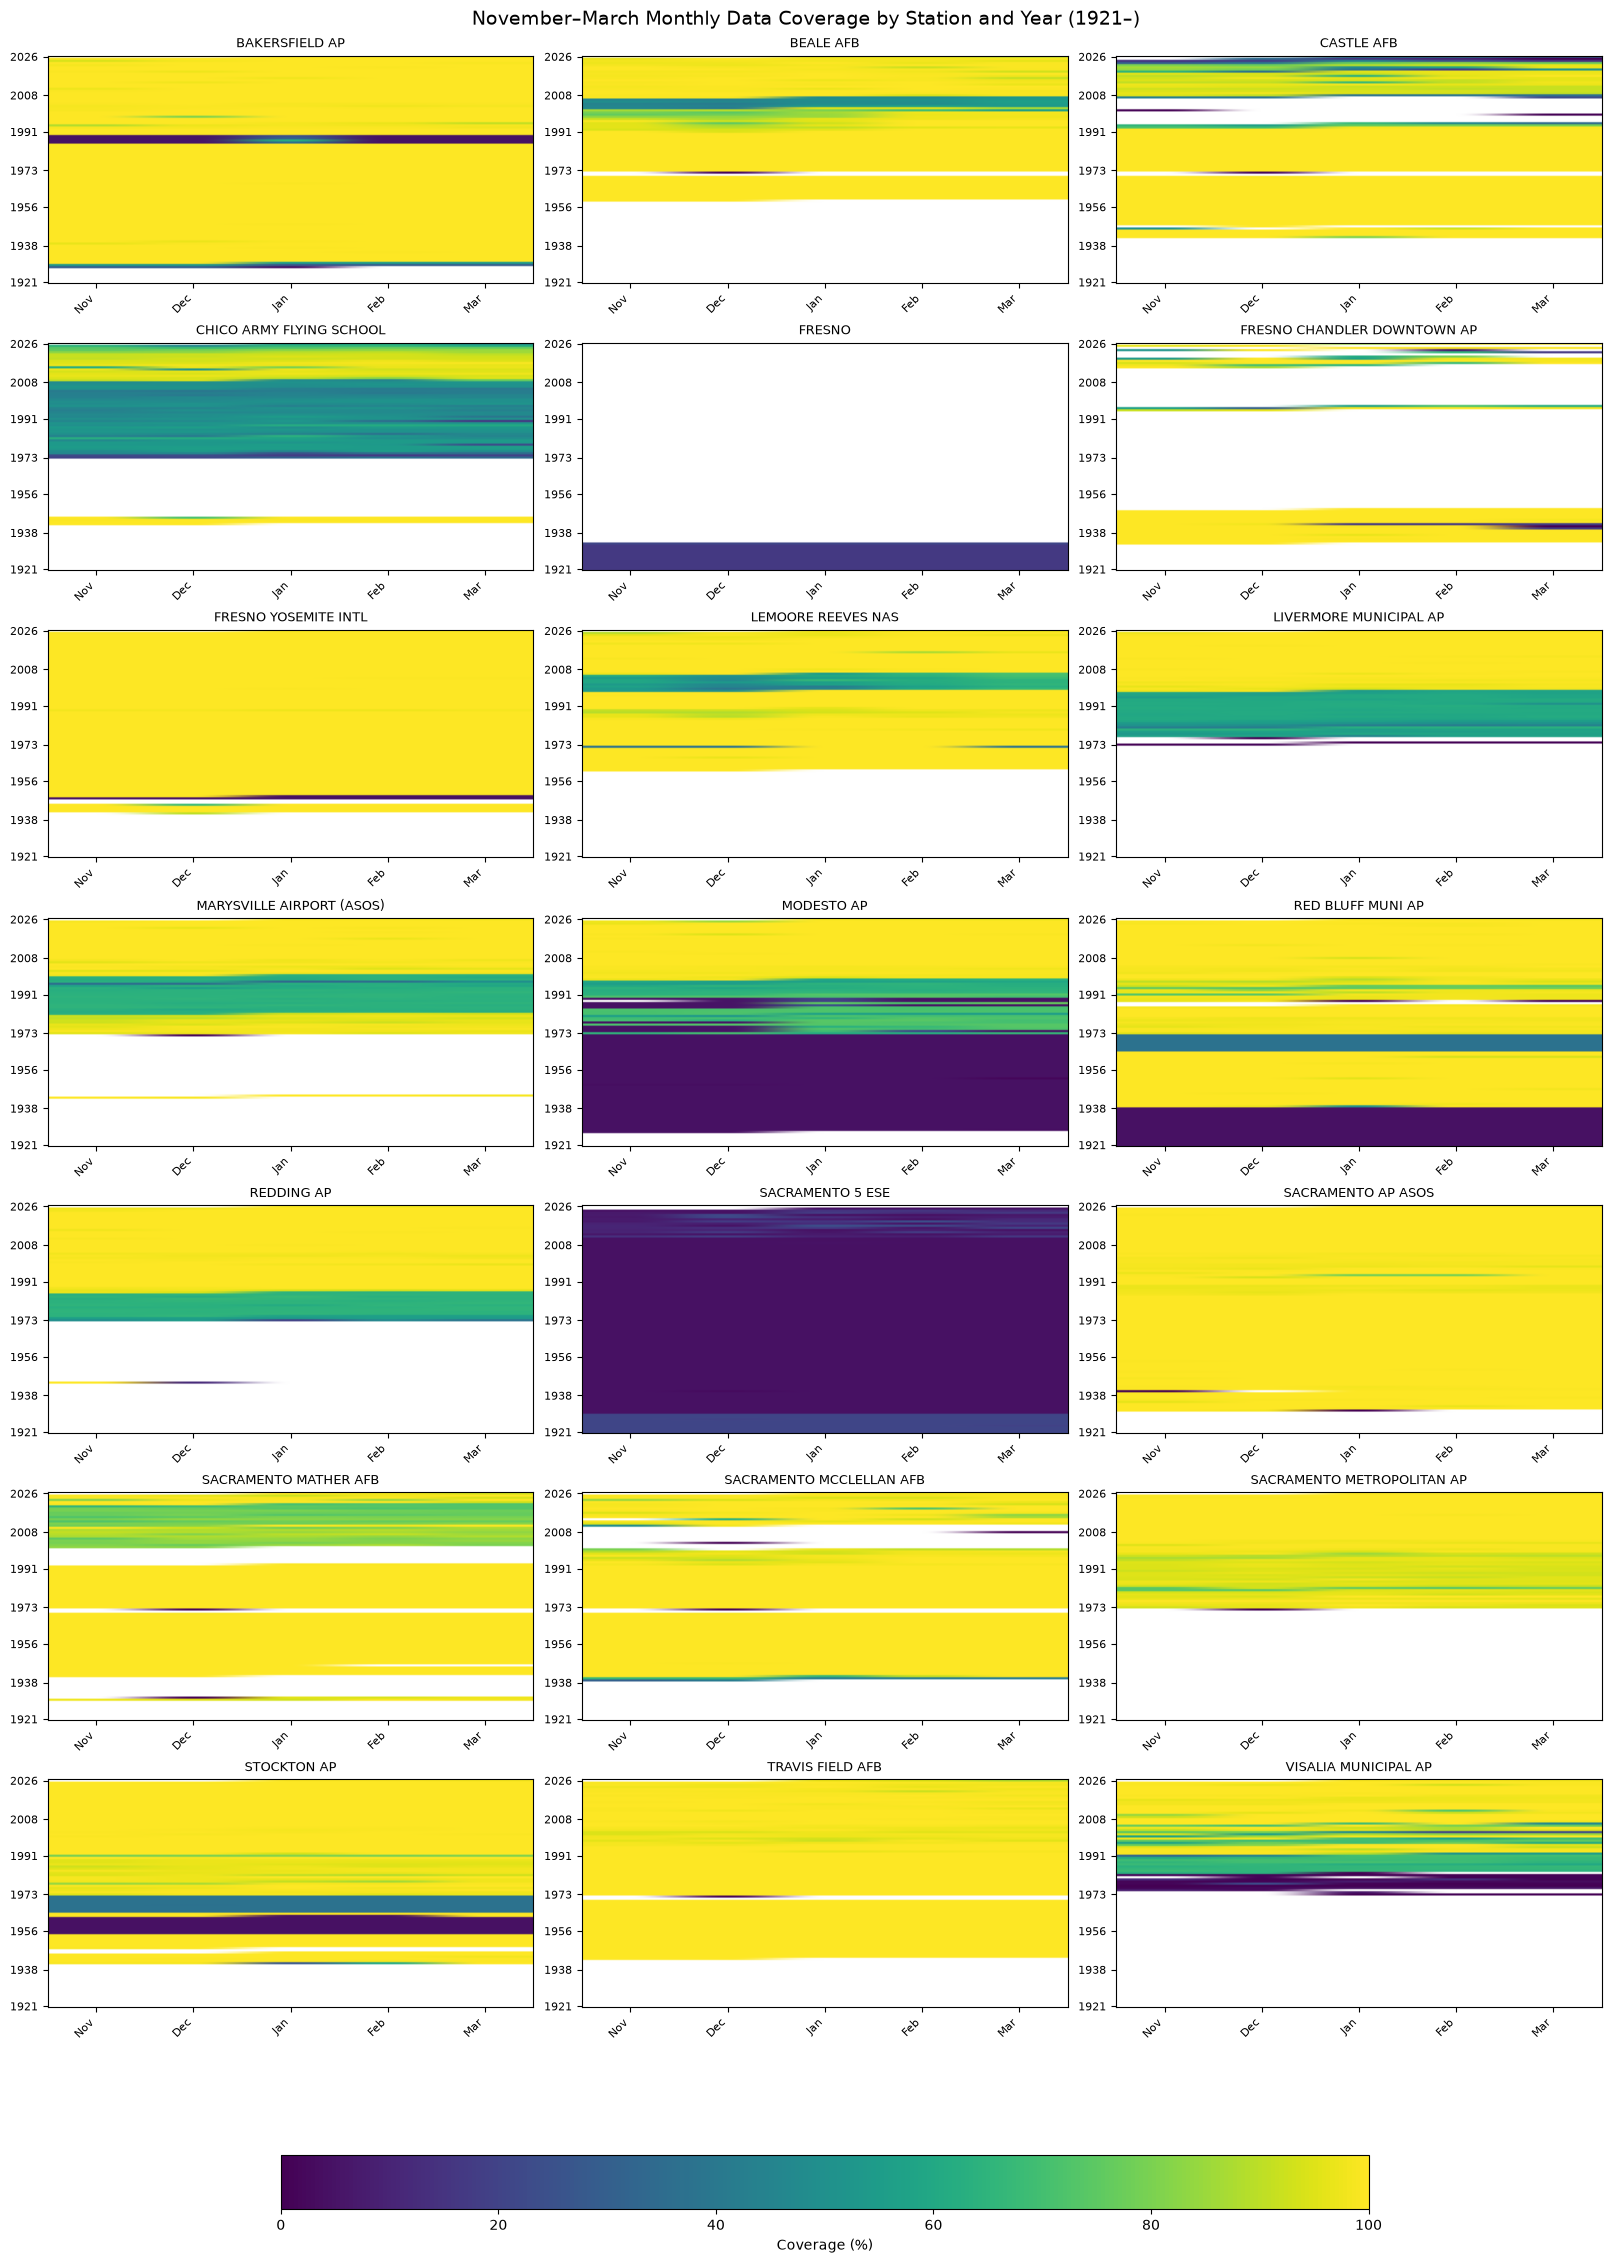

In [9]:
# Heatmap of November–March coverage by station and year
# Missing station-month years are shown in white.

# Only use months of fog season (November to March)
fog_months = [11, 12, 1, 2, 3]
# Label fog season months
fog_month_labels = ["Nov", "Dec", "Jan", "Feb", "Mar"]

# Use stations with long-term data and sort them (meaning sorted alphabetically by station name) 
stations_fog = sorted(stations_pre1975)
# Use years from 1900 to the maximum year in the monthly_coverage DataFrame
years_fog = range(1921, int(monthly_coverage["year"].max()) + 1)

# Set up the colorbar for the heatmap
# Use viridis colormap 
cmap = plt.cm.viridis.copy()
# Set missing data to white
cmap.set_bad("white")
# Only use stations with at least 10 years of data (stations already include data back to at least 1975)
stations_fog = [st for st in stations_fog if monthly_coverage[monthly_coverage["STATION"] == st]["year"].nunique() >= 10]
# Define number of stations
n_stations = len(stations_fog)
# Define number of columns and rows for the heatmap subplots
# Defining columns:
ncols = 3
# Determining rows:
nrows = int(np.ceil(n_stations / ncols))

# Create subplots for the heatmap
fig, axes = plt.subplots(
    # set number of rows and columns
    nrows, ncols,
    # Set the figure size based on the number of rows
    figsize=(16, nrows * 3.2),
    # constrained layout to prevent overlapping of subplots and labels
    constrained_layout=True
)
# Reshape axes to a 1D array for easier indexing
# (each subplot can be accessed using a single index rather than a row-column pair)
axes = np.asarray(axes).reshape(-1)

# Loop through each station and create a heatmap for its monthly coverage
for i, station in enumerate(stations_fog):
    # Get the corresponding axis for the current station
    # (the subplot where the heatmap for this station will be drawn)
    ax = axes[i]

# determine station_data from monthly_coverage for the current station and years >= 1900
    station_data = monthly_coverage[
        (monthly_coverage["STATION"] == station) &
        (monthly_coverage["year"] >= 1921)
    ]
# create a pivot table heatmap_data
    heatmap_data = (
        # use station_data
        station_data
        # Create a pivot table with years as rows, months as columns, and coverage percentage as values
        .pivot(index="year", columns="month", values="coverage_pct")
        # reindex the table to include missing values to show gaps
        .reindex(index=years_fog, columns=fog_months)
    )

# imshow will display the heatmap data as an image on the subplot axis
    im = ax.imshow(
        # convert the heatmap_data DataFrame to a NumPy array for imshow
        heatmap_data.to_numpy(),
        # set the aspect ratio of the heatmap to 'auto' so that it fills the subplot
        # (the heatmap will automatically adjust its aspect ratio to fit the subplot dimensions)
        aspect="auto",
        # set the origin of the heatmap to 'lower' so that the first row of data is at the bottom of the subplot
        origin="lower",
        # vmin and vmax set the range of values for the colormap from the viridis colormap
        vmin=0,
        vmax=100,
        # set the colormap to the viridis colormap with missing data shown in white as defined before
        cmap=cmap
    )

    # Set the title of the subplot to the station name with a smaller font size
    ax.set_title(station, fontsize=9)
    # Set the x-ticks and x-tick labels for the months of the fog season
    ax.set_xticks(range(len(fog_months)))
    # Set the x-tick labels to the fog month labels
    # Use a 45-degree rotation and right alignment for better readability
    ax.set_xticklabels(fog_month_labels, rotation=45, ha="right", fontsize=8)

    # Define year_list to be used for y-ticks
    year_list = list(years_fog)
    # y-ticks are set to show a maximum of 7 years on the y-axis for better readability
    y_ticks = np.linspace(0, len(year_list) - 1, min(7, len(year_list))).astype(int)
    # Set the y-ticks and y-tick labels for the years of the fog season
    ax.set_yticks(y_ticks)
    # Set the y-tick labels to the corresponding years
    ax.set_yticklabels([year_list[j] for j in y_ticks], fontsize=8)

# Remove any unused subplots if the number of stations is less than the total number of subplots created
for ax in axes[n_stations:]:
    # delaxes removes the specified axis from the figure
    fig.delaxes(ax)

# Add a colorbar to the figure to indicate the coverage percentage
cbar = fig.colorbar(im, ax=axes[:n_stations], location="bottom", shrink=0.7, pad=0.05)
# Set the label for the colorbar to indicate that it represents coverage percentage
cbar.set_label("Coverage (%)")

# Add title
fig.suptitle(
    "November–March Monthly Data Coverage by Station and Year (1921–)",
    fontsize=14
)
# show the plot
plt.show()

In [8]:
# Diagnose why FRESNO has no monthly coverage percentages

fresno_rows = CV_rows[CV_rows["STATION"].astype(str).str.strip().str.upper() == "FRESNO"].copy()

print("Fresno rows in CV_rows:", len(fresno_rows))
print("Fresno years in CV_rows:", fresno_rows["year"].min(), "to", fresno_rows["year"].max())
print("Fresno rows by year:")
print(fresno_rows.groupby("year").size().head(15))

# Check whether DATE can be parsed
fresno_rows["parsed_DATE"] = pd.to_datetime(fresno_rows["DATE"], errors="coerce")

print("\nInvalid Fresno dates:", fresno_rows["parsed_DATE"].isna().sum())
print("Valid Fresno dates:", fresno_rows["parsed_DATE"].notna().sum())

# Compare station names in the coverage table
print("\nStation names containing 'FRESNO' in monthly_coverage:")
print(
    monthly_coverage[
        monthly_coverage["STATION"].astype(str).str.contains("FRESNO", case=False, na=False)
    ]["STATION"].unique()
)

# Check coverage records specifically for Fresno
fresno_coverage = monthly_coverage[
    monthly_coverage["STATION"].astype(str).str.strip().str.upper() == "FRESNO"
]

print("\nFresno rows in monthly_coverage:", len(fresno_coverage))
print("Fresno coverage years:")
print(fresno_coverage["year"].unique())

print("\nFresno coverage records:")
print(fresno_coverage.head())

Fresno rows in CV_rows: 60381
Fresno years in CV_rows: 1893 to 1939
Fresno rows by year:
year
1893    1460
1894    1460
1895    1460
1896    1464
1897    1460
1898    1460
1899    1460
1900    1460
1901    1460
1902    1460
1903    1460
1904    1464
1905    1460
1906    1460
1907    1460
dtype: int64

Invalid Fresno dates: 0
Valid Fresno dates: 60381

Station names containing 'FRESNO' in monthly_coverage:
<StringArray>
['FRESNO', 'FRESNO CHANDLER DOWNTOWN AP', 'FRESNO YOSEMITE INTL']
Length: 3, dtype: str

Fresno rows in monthly_coverage: 493
Fresno coverage years:
[1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905 1906
 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919 1920
 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933 1939]

Fresno coverage records:
     STATION  year  month  observed_hours month_start  expected_hours  \
3482  FRESNO  1893      1             124  1893-01-01             744   
3483  FRESNO  1893      2             112 

C:\Users\Work Account\AppData\Local\Temp\ipykernel_21844\2909697554.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


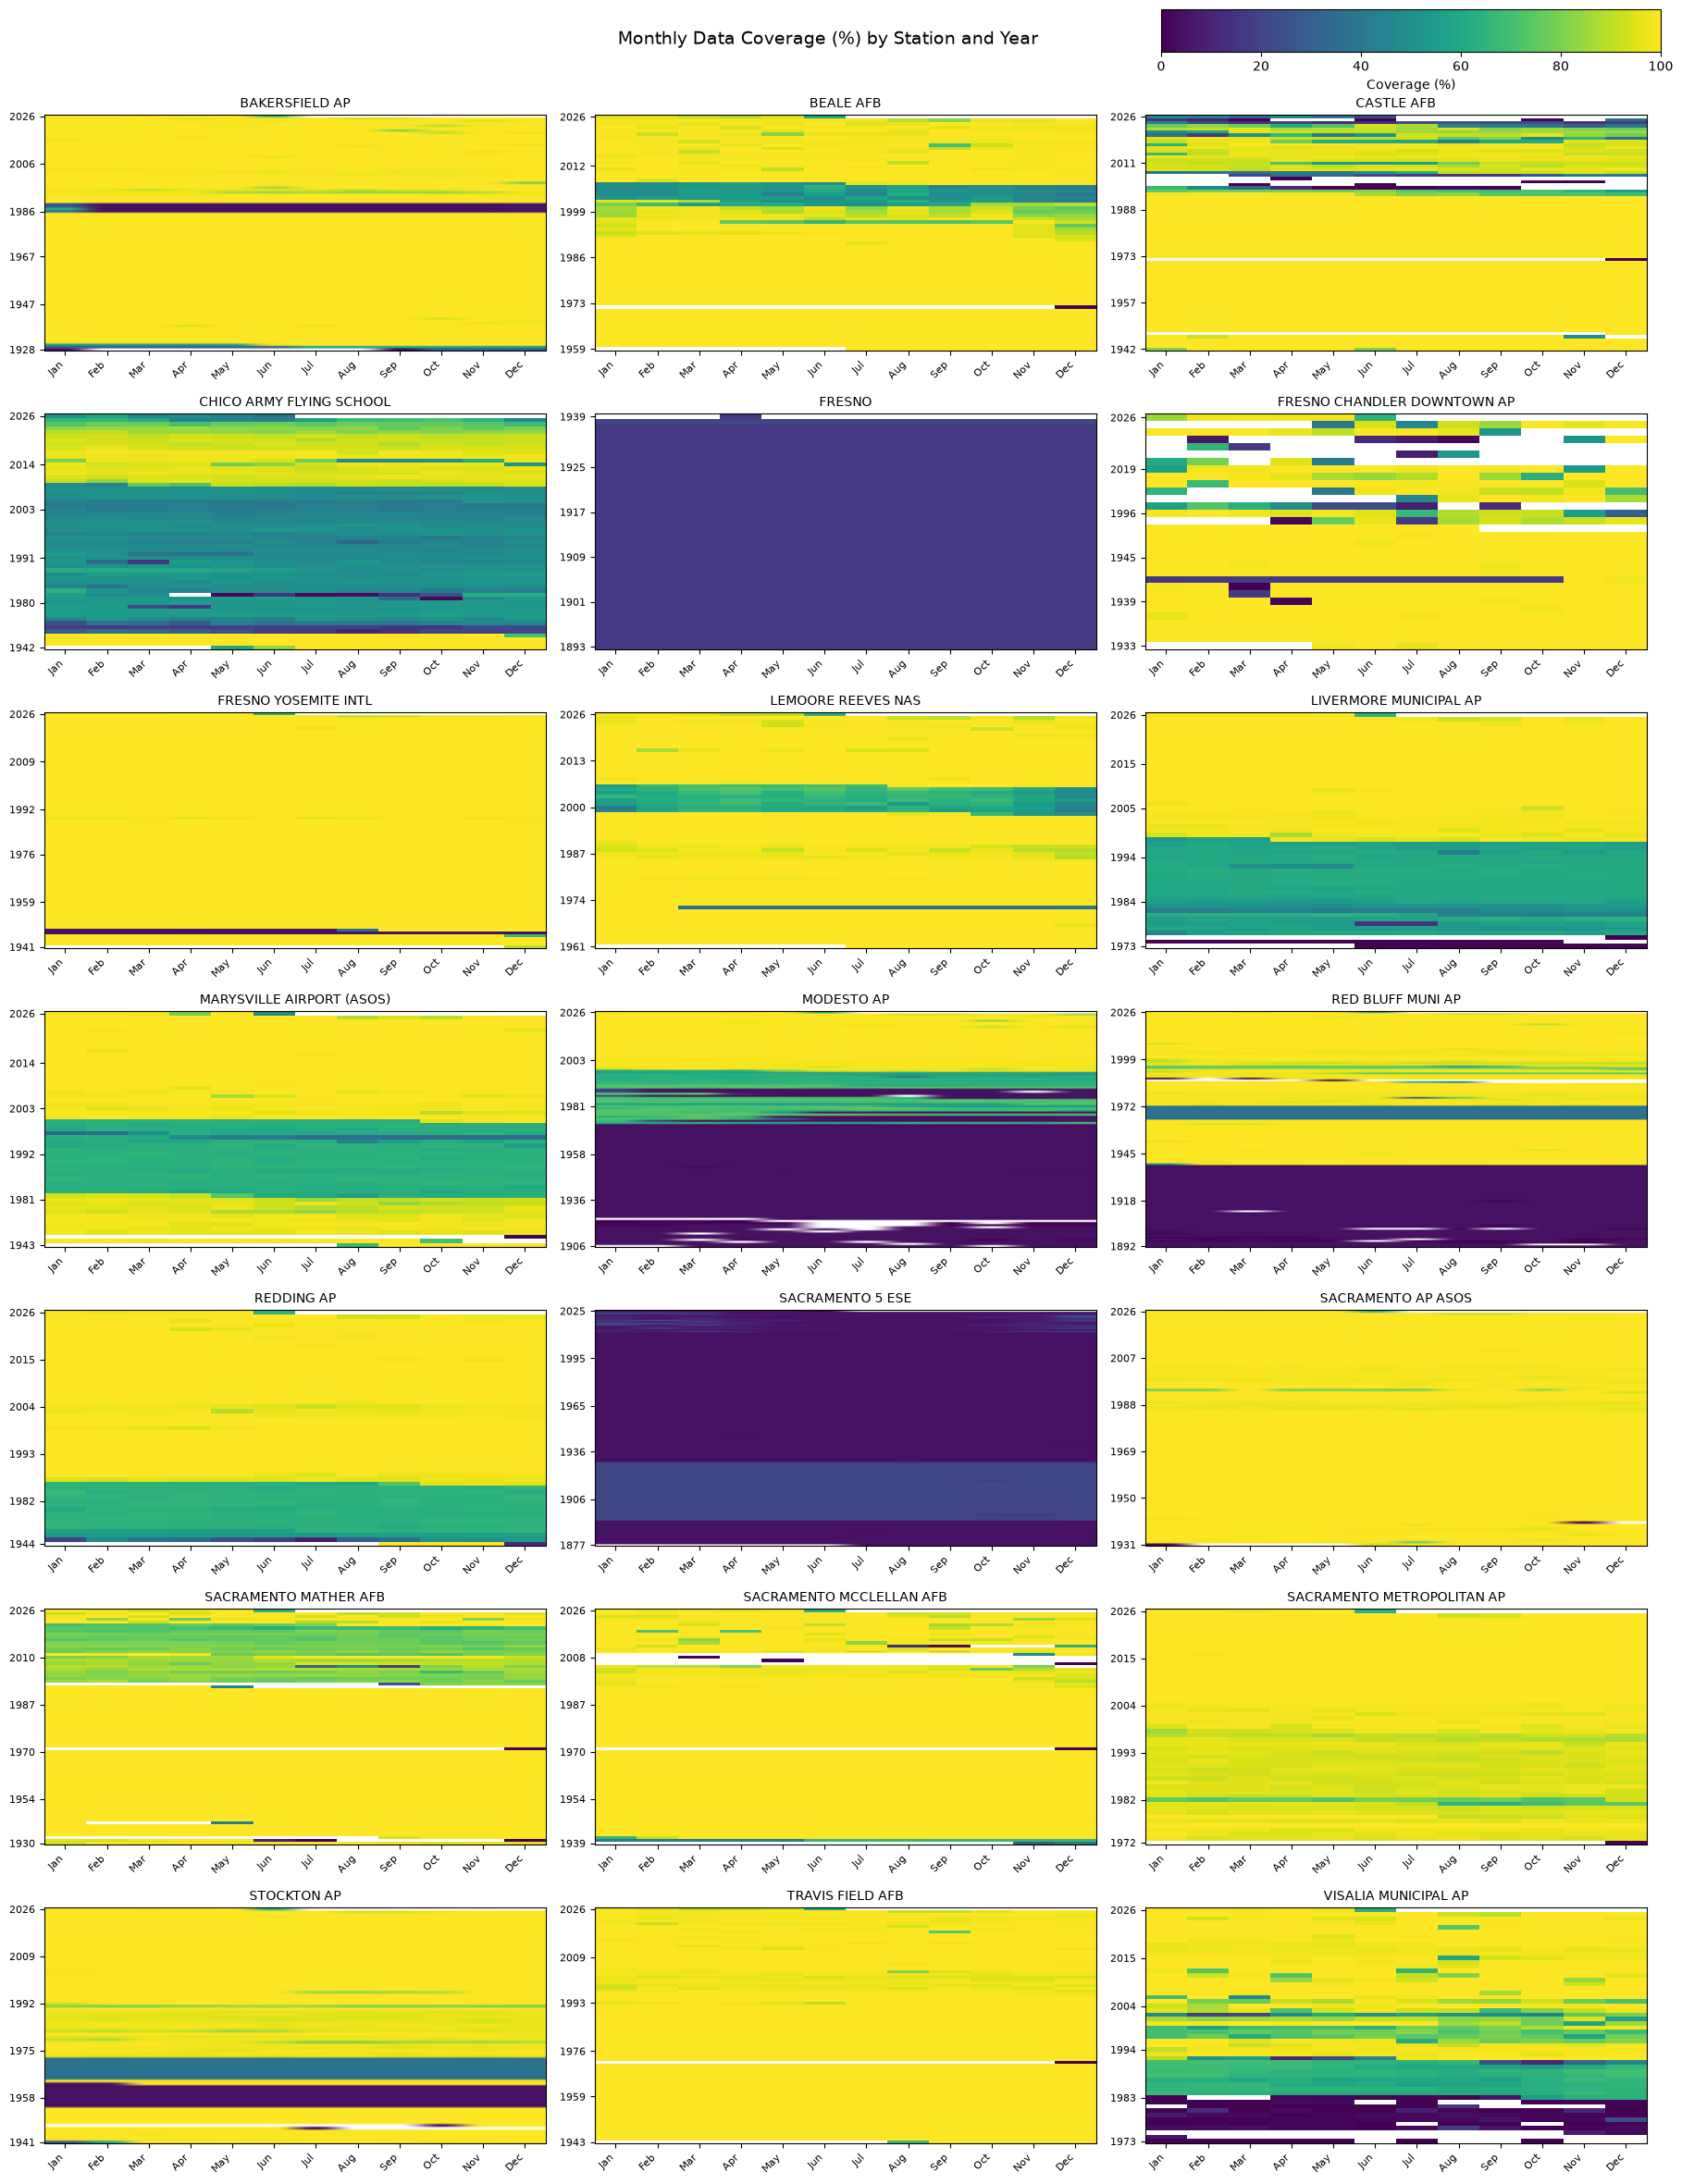

In [26]:
# Plot: one heatmap per station (year x month)
stations_cov = sorted(monthly_coverage["STATION"].unique())
# use stations with data back to at least 1970
stations_cov = [st for st in stations_cov if st in stations_pre1975]
#exclude stations with less than 10 years of data
stations_cov = [st for st in stations_cov if monthly_coverage[monthly_coverage["STATION"] == st]["year"].nunique() >= 10]
n_stations = len(stations_cov)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.3))
axes = np.array(axes).reshape(-1)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for i, st in enumerate(stations_cov):
    ax = axes[i]
    st_df = monthly_coverage[monthly_coverage["STATION"] == st]
    pivot = (
        st_df.pivot(index="year", columns="month", values="coverage_pct")
        .reindex(columns=range(1, 13))
        .sort_index()
    )

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=100,
        cmap="viridis"
    )

    ax.set_title(st, fontsize=10)
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)

    if len(pivot.index) > 0:
        y_idx = np.linspace(0, len(pivot.index) - 1, min(6, len(pivot.index))).astype(int)
        ax.set_yticks(y_idx)
        ax.set_yticklabels(pivot.index[y_idx], fontsize=8)
    else:
        ax.set_yticks([])

for ax in axes[n_stations:]:
    fig.delaxes(ax)

#make color bar at the bottom right of the figures
cax = fig.add_axes([0.7, 1, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
cbar.set_label("Coverage (%)")

fig.suptitle("Monthly Data Coverage (%) by Station and Year", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_21844\3946605388.py:28: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
C:\Users\Work Account\AppData\Local\Temp\ipykernel_21844\3946605388.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


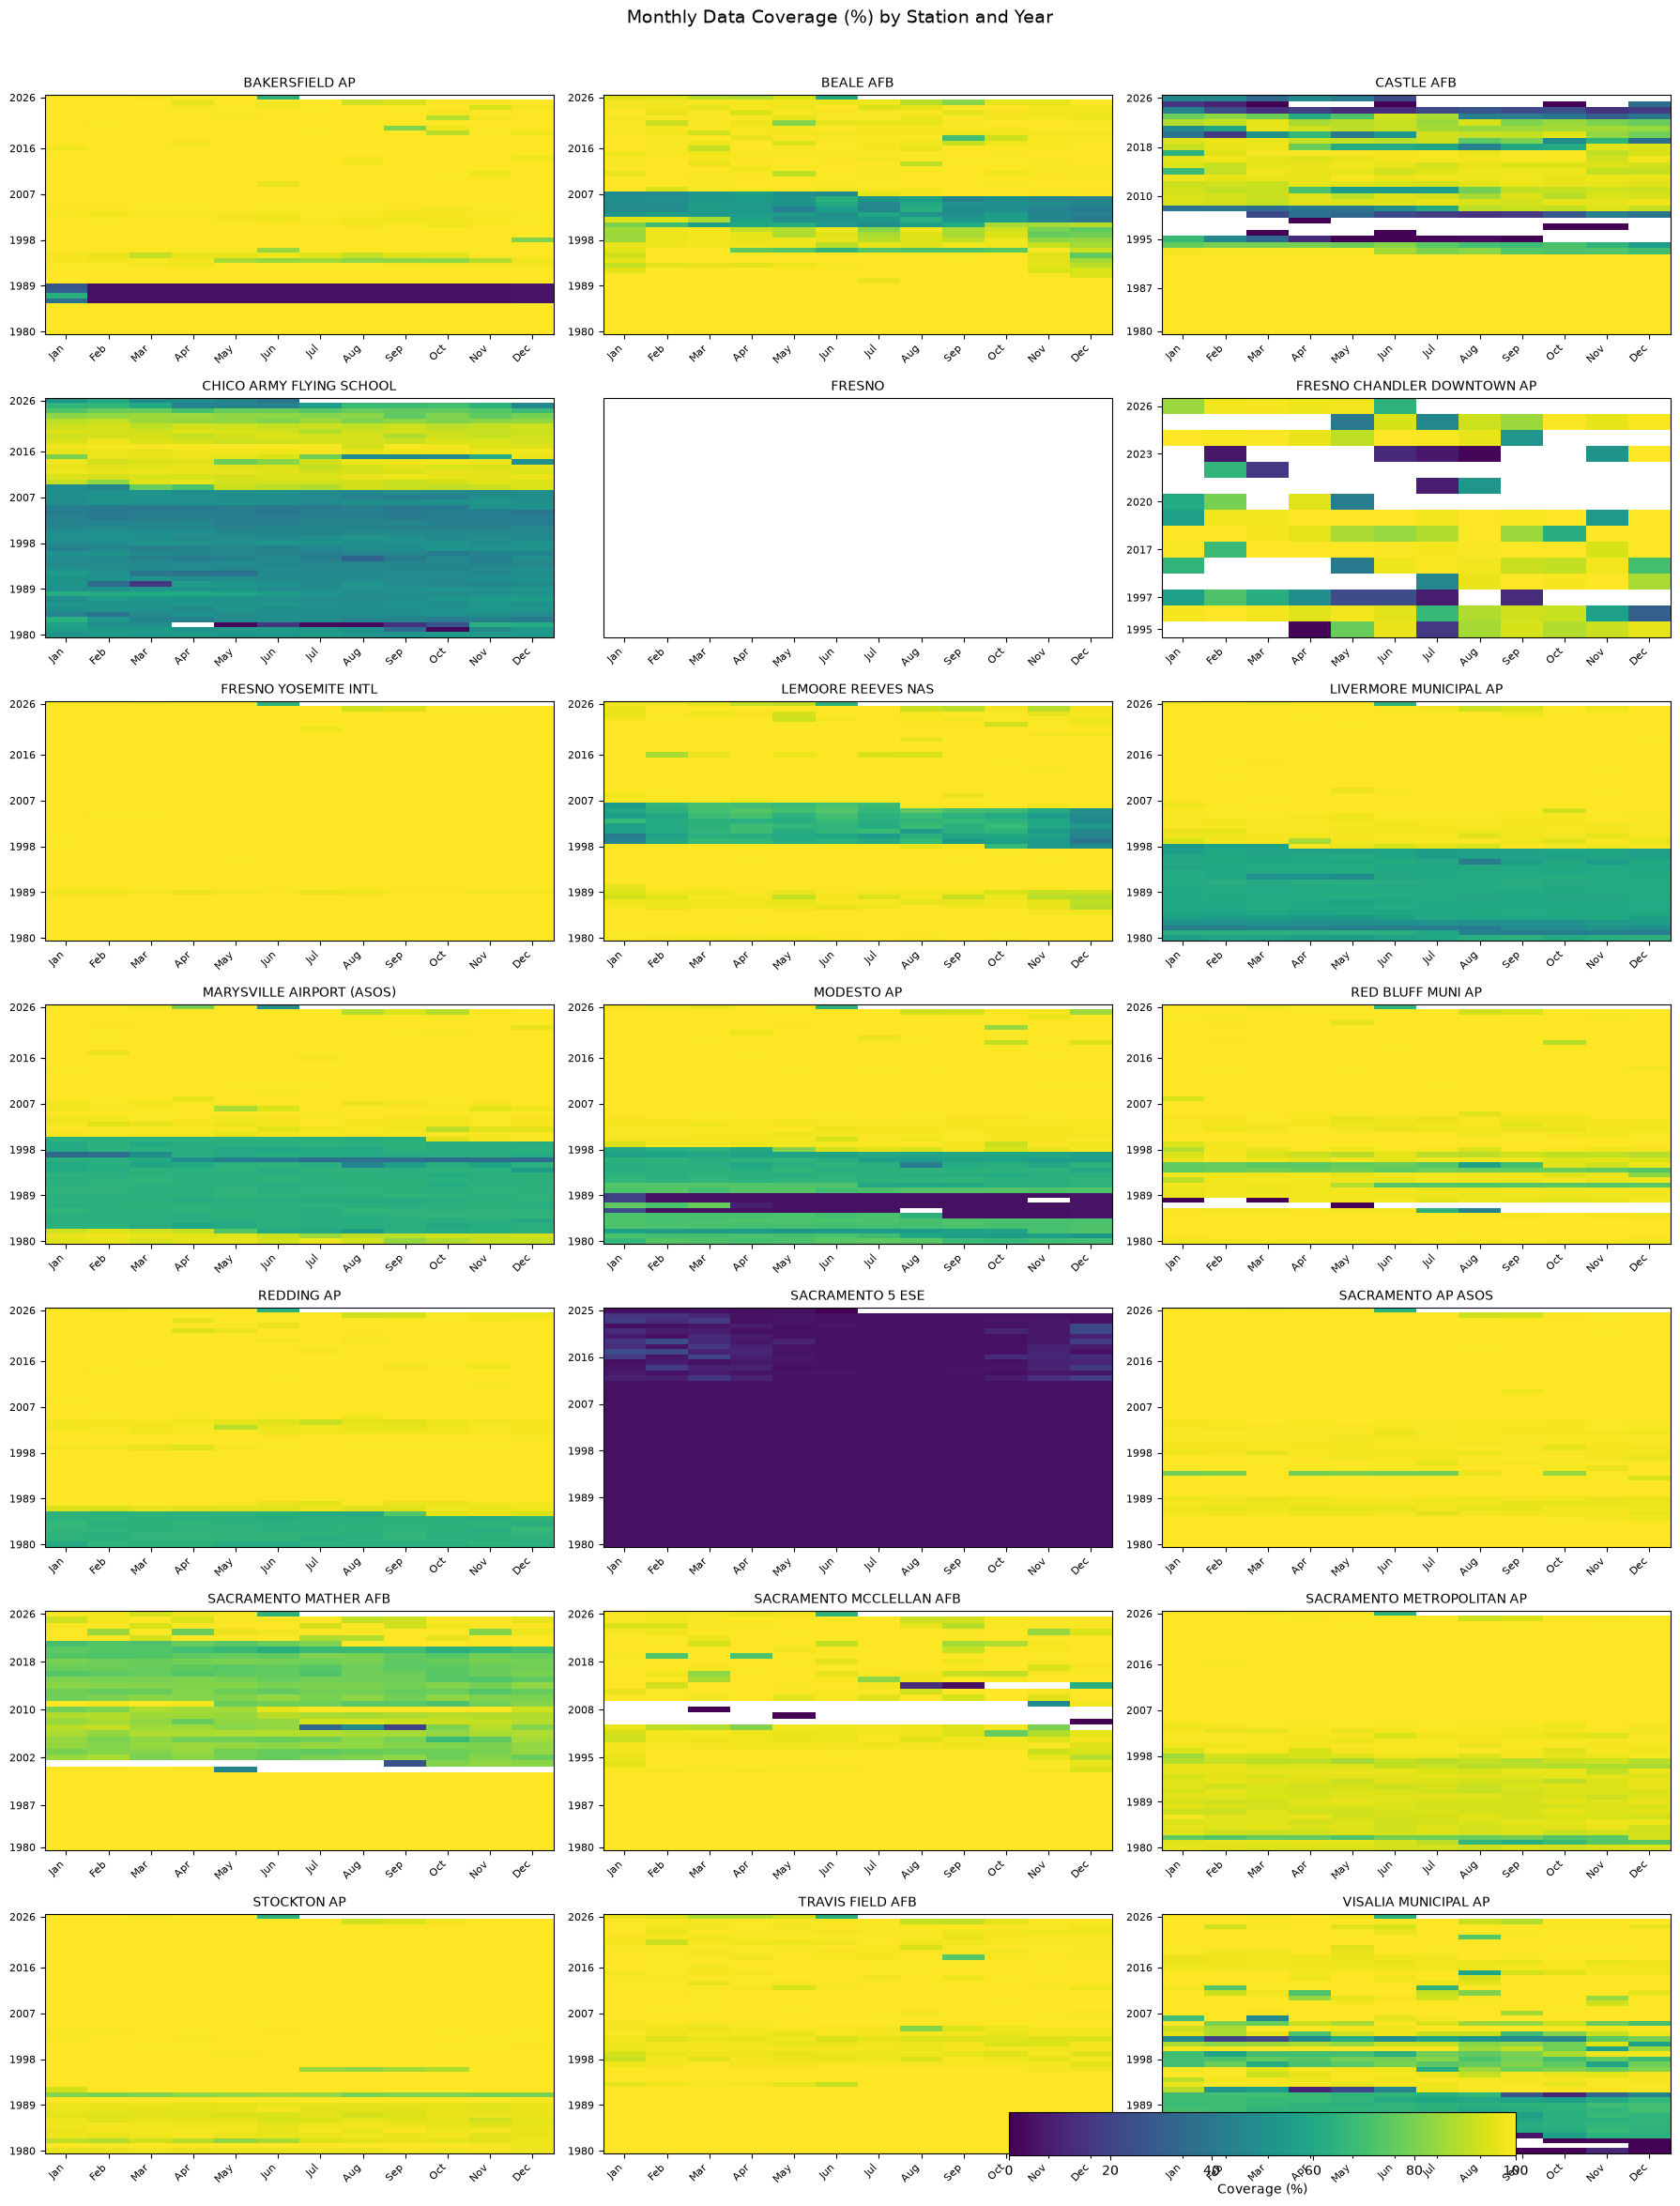

In [11]:
# Plot: one heatmap per station (year x month)
stations_cov = sorted(monthly_coverage["STATION"].unique())
# use stations with data back to at least 1975
stations_cov = [st for st in stations_cov if st in stations_pre1975]
#exclude stations with less than 10 years of data
stations_cov = [st for st in stations_cov if monthly_coverage[monthly_coverage["STATION"] == st]["year"].nunique() >= 10]
n_stations = len(stations_cov)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.3))
axes = np.array(axes).reshape(-1)

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for i, st in enumerate(stations_cov):
    ax = axes[i]
    st_df = monthly_coverage[monthly_coverage["STATION"] == st]
    #only plot years since 1980
    st_df = st_df[st_df["year"] >= 1980]
    pivot = (
        st_df.pivot(index="year", columns="month", values="coverage_pct")
        .reindex(columns=range(1, 13))
        .sort_index()
    )

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=100,
        cmap="viridis"
    )

    ax.set_title(st, fontsize=10)
    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)

    if len(pivot.index) > 0:
        y_idx = np.linspace(0, len(pivot.index) - 1, min(6, len(pivot.index))).astype(int)
        ax.set_yticks(y_idx)
        ax.set_yticklabels(pivot.index[y_idx], fontsize=8)
    else:
        ax.set_yticks([])

for ax in axes[n_stations:]:
    fig.delaxes(ax)

#make color bar at the bottom right of the figures
cax = fig.add_axes([0.6, 0.02, 0.3, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation="horizontal",fraction=0.02, pad=0.04)
cbar.set_label("Coverage (%)")

fig.suptitle("Monthly Data Coverage (%) by Station and Year", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

C:\Users\Work Account\AppData\Local\Temp\ipykernel_21844\67574615.py:32: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
C:\Users\Work Account\AppData\Local\Temp\ipykernel_21844\67574615.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


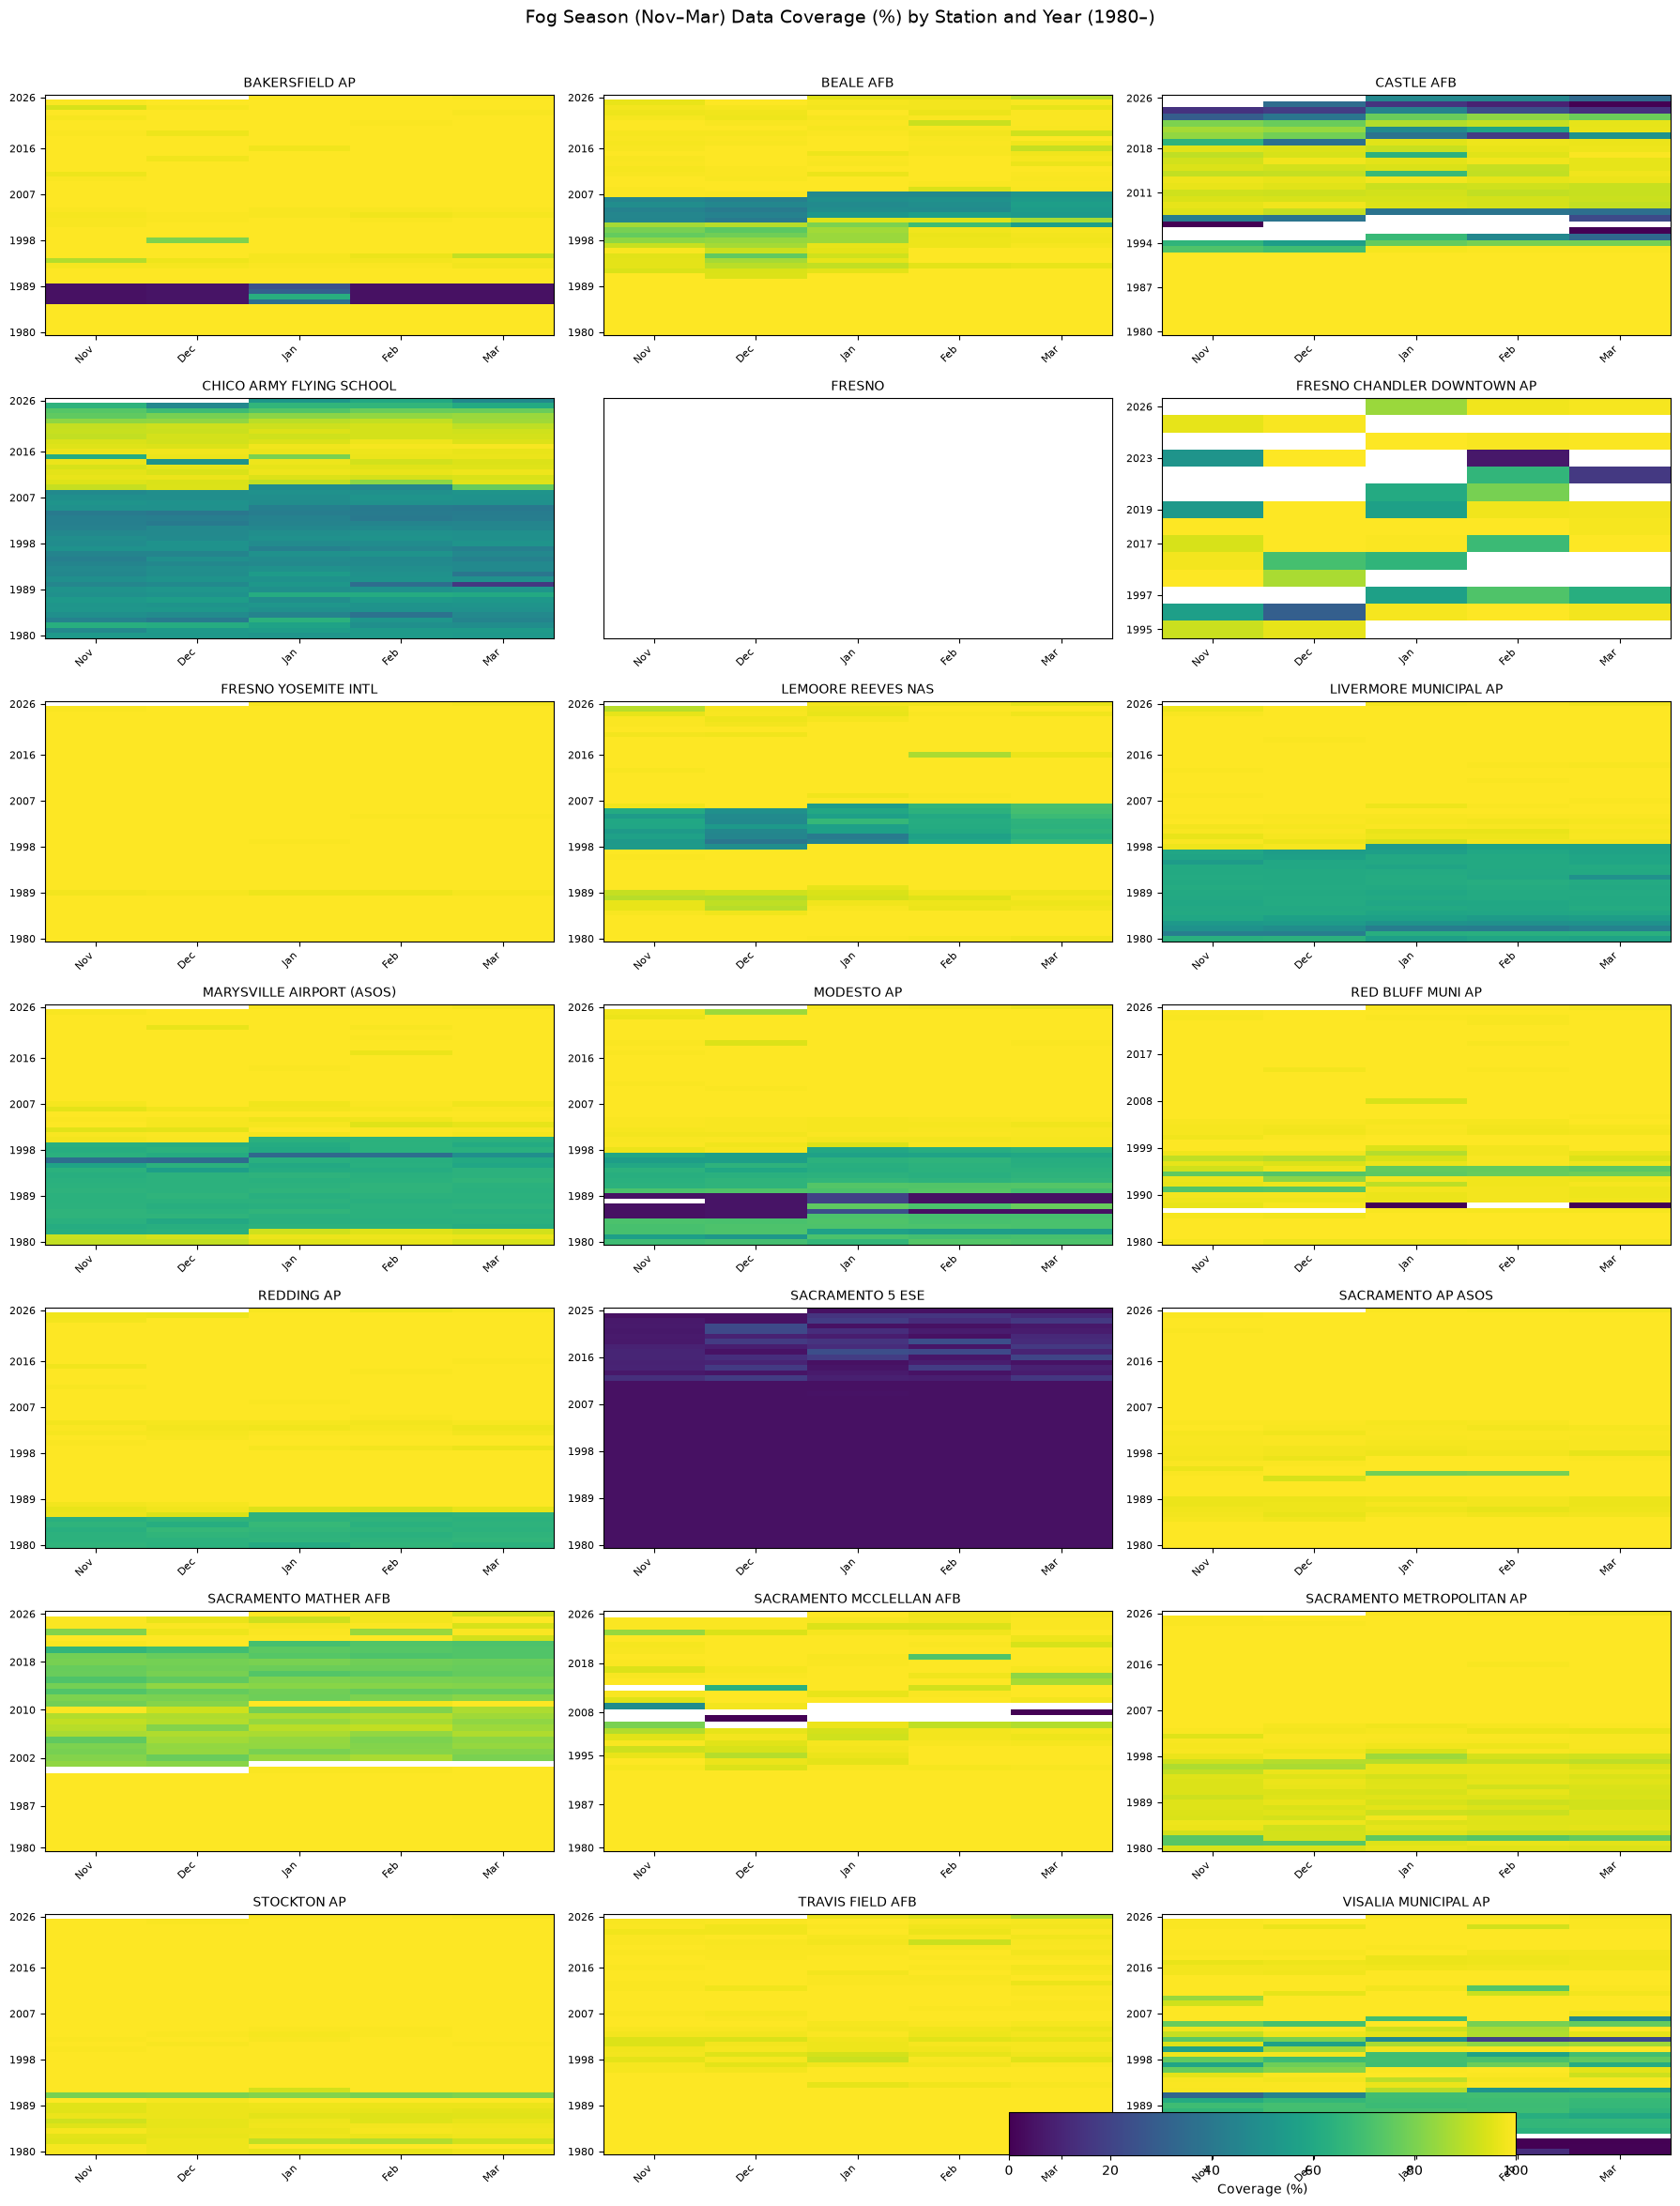

In [12]:
# Plot: heatmap of fog-season (Nov-Mar) monthly coverage per station (year x month)
# Only years from 1980 onward, only stations with data back to at least 1970

fog_season_months = [11, 12, 1, 2, 3]
fog_month_labels = ["Nov", "Dec", "Jan", "Feb", "Mar"]

stations_fog = sorted([st for st in monthly_coverage["STATION"].unique() if st in stations_pre1975])
# exclude stations with less than 10 years of data
stations_fog = [st for st in stations_fog if monthly_coverage[monthly_coverage["STATION"] == st]["year"].nunique() >= 10]

n_stations = len(stations_fog)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.3))
axes = np.array(axes).reshape(-1)

for i, st in enumerate(stations_fog):
    ax = axes[i]
    st_df = monthly_coverage[
        (monthly_coverage["STATION"] == st) &
        (monthly_coverage["year"] >= 1980) &
        (monthly_coverage["month"].isin(fog_season_months))
    ]

    pivot = (
        st_df.pivot(index="year", columns="month", values="coverage_pct")
        .reindex(columns=fog_season_months)
        .sort_index()
    )

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=100,
        cmap="viridis"
    )

    ax.set_title(st, fontsize=10)
    ax.set_xticks(np.arange(len(fog_season_months)))
    ax.set_xticklabels(fog_month_labels, rotation=45, ha="right", fontsize=8)

    if len(pivot.index) > 0:
        y_idx = np.linspace(0, len(pivot.index) - 1, min(6, len(pivot.index))).astype(int)
        ax.set_yticks(y_idx)
        ax.set_yticklabels(pivot.index[y_idx], fontsize=8)
    else:
        ax.set_yticks([])

for ax in axes[n_stations:]:
    fig.delaxes(ax)

cax = fig.add_axes([0.6, 0.02, 0.3, 0.02])
cbar = fig.colorbar(im, cax=cax, orientation="horizontal", fraction=0.02, pad=0.04)
cbar.set_label("Coverage (%)")

fig.suptitle("Fog Season (Nov–Mar) Data Coverage (%) by Station and Year (1980–)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# Keep only station-year periods with >=90% coverage in all winter months (Nov-Mar)

winter_months = [11, 12, 1, 2, 3]

station_year_winter_cov90 = (
    monthly_coverage[monthly_coverage["month"].isin(winter_months)]
    .groupby(["STATION", "year"], as_index=False)["coverage_pct"]
    .min()
    .loc[lambda d: d["coverage_pct"] >= 90]
    .sort_values(["STATION", "year"])
    .reset_index(drop=True)
)

winter_station_years = station_year_winter_cov90[["STATION", "year"]].drop_duplicates()

CV_rows_winter_cov90 = CV_rows.merge(
    winter_station_years,
    on=["STATION", "year"],
    how="inner"
)

print("Station-years with winter coverage >=90%:", station_year_winter_cov90.shape)
print("Filtered CV_rows_winter_cov90 shape:", CV_rows_winter_cov90.shape)

Station-years with winter coverage >=90%: (1136, 3)
Filtered CV_rows_winter_cov90 shape: (11924415, 17)


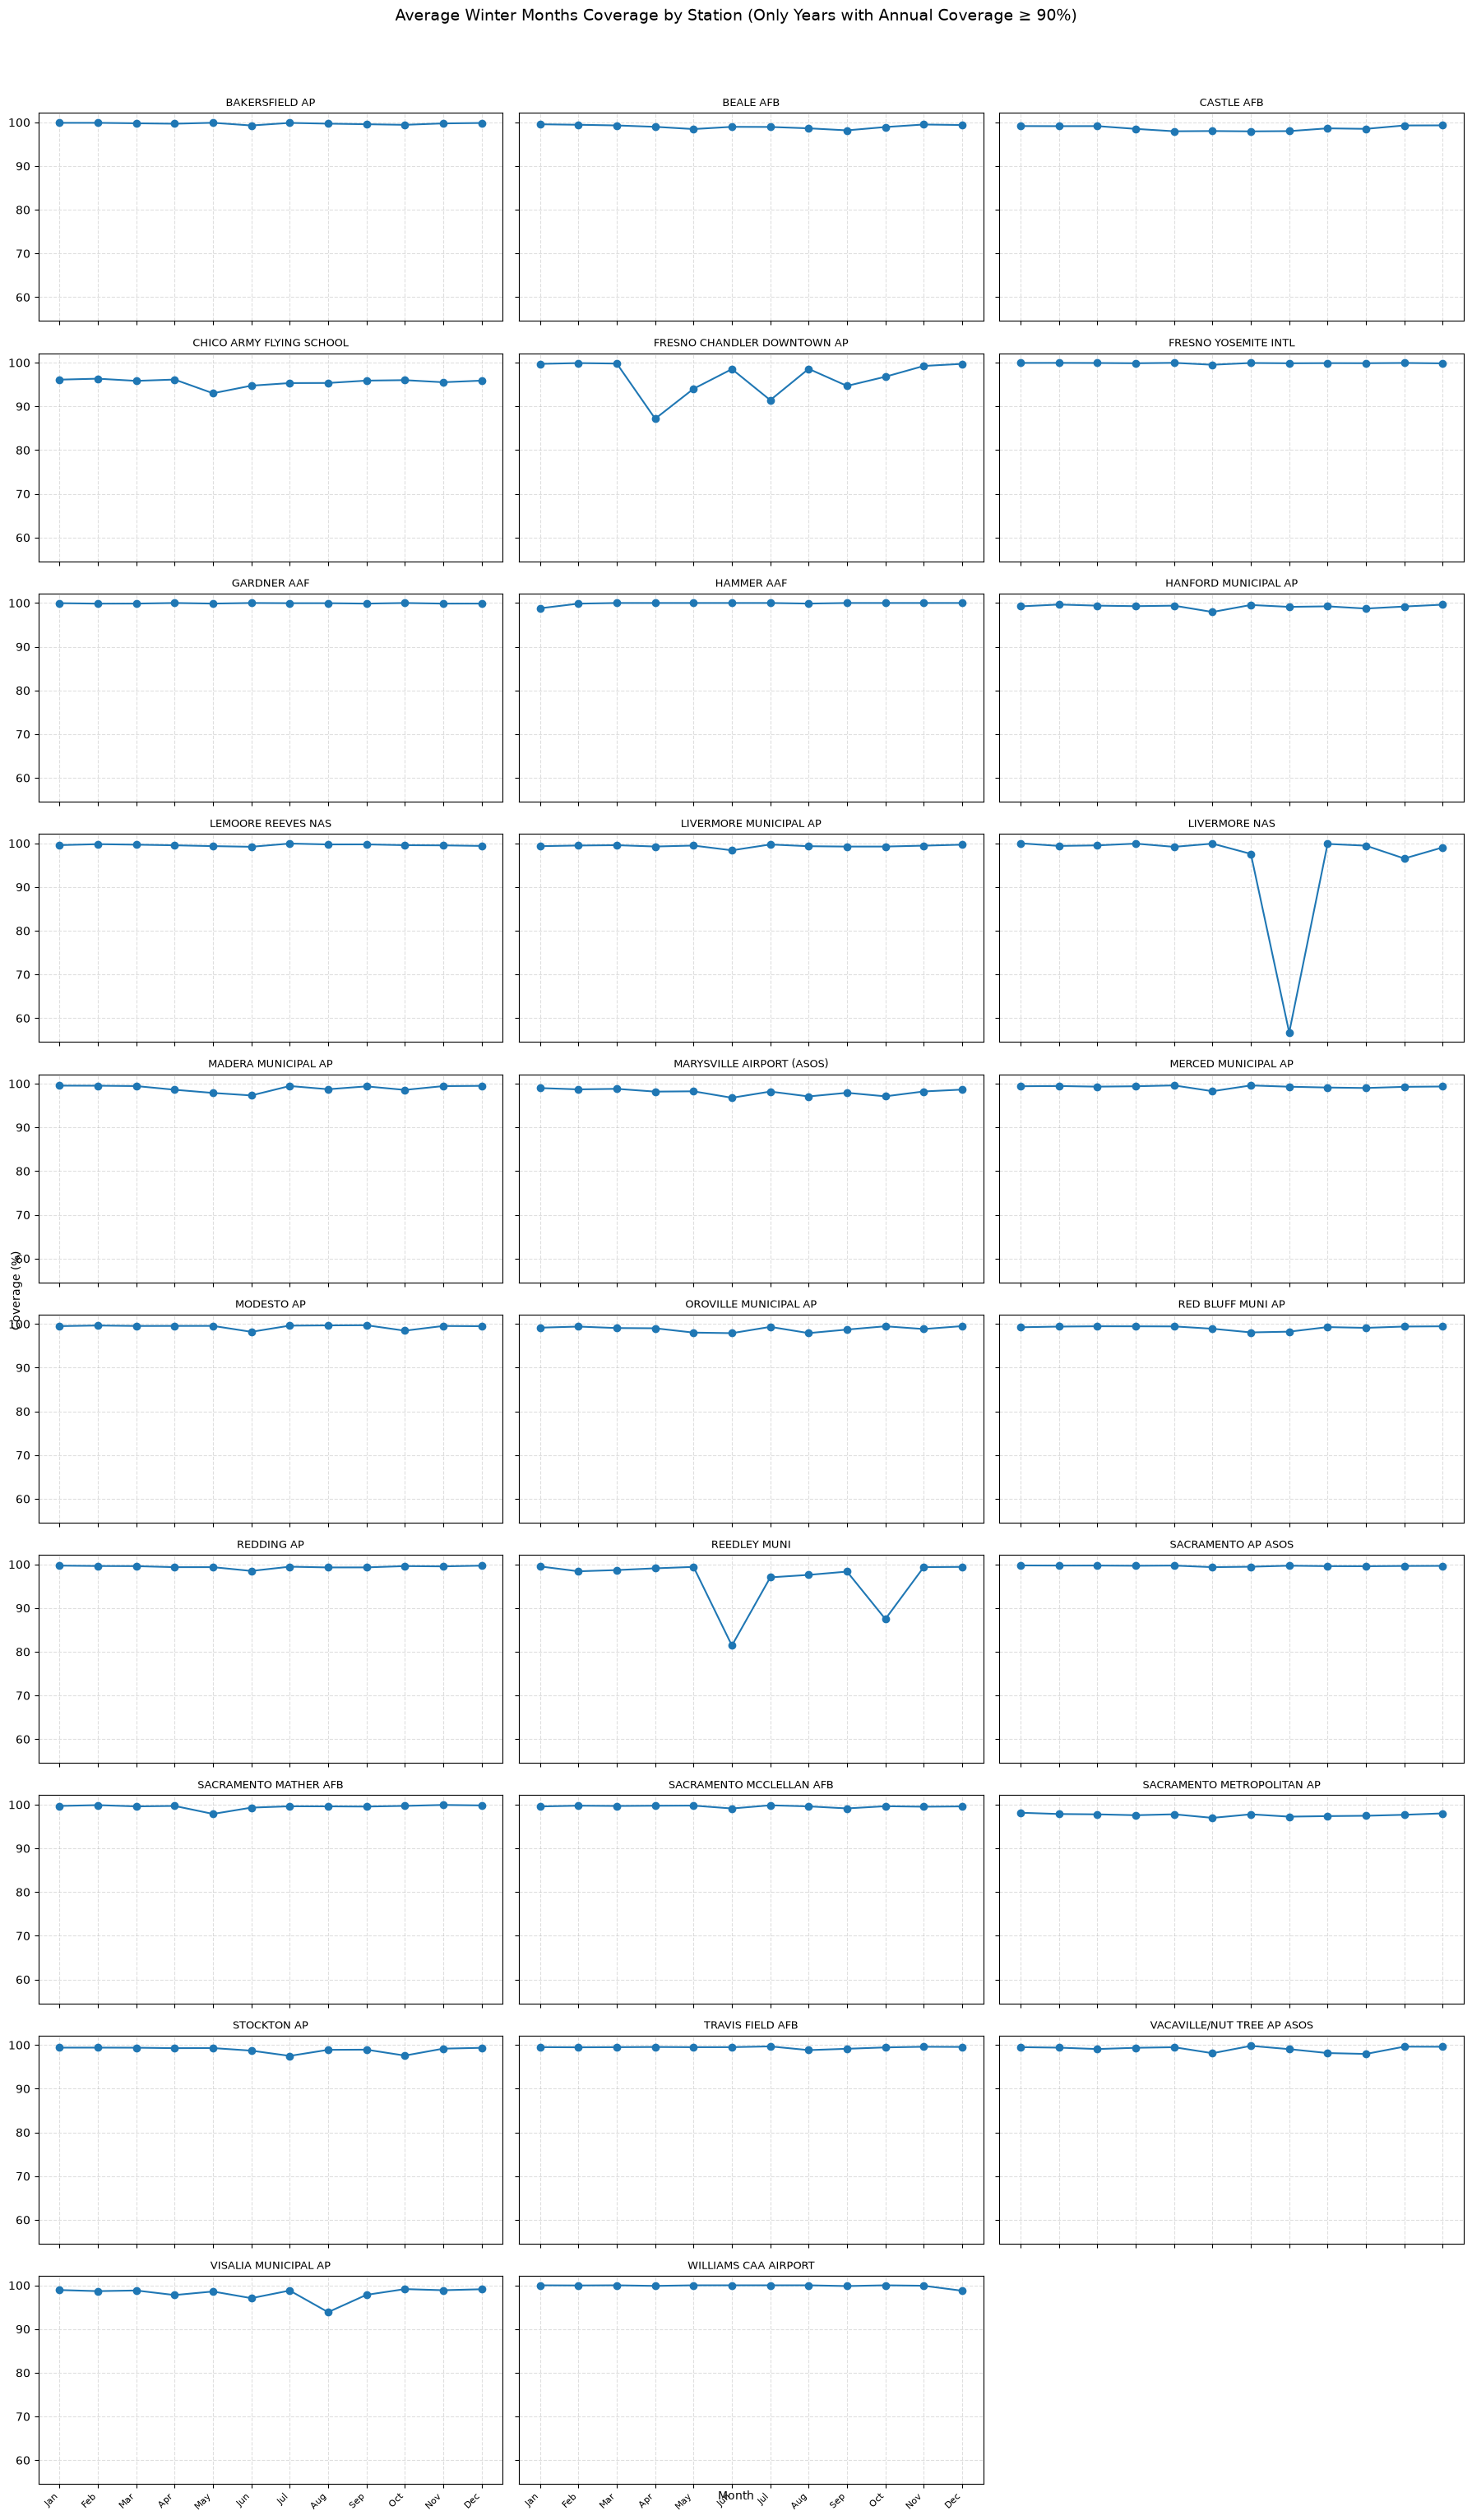

In [14]:
# Keep only station-year combinations with >=90% annual coverage
eligible_station_years = station_year_winter_cov90[["STATION", "year"]].drop_duplicates()

# Monthly coverage restricted to eligible years
monthly_winter_cov_90yr = monthly_coverage.merge(
    eligible_station_years,
    on=["STATION", "year"],
    how="inner"
)

# Average monthly coverage by station (across eligible years)
monthly_winter_cov_90yr_summary = (
    monthly_winter_cov_90yr
    .groupby(["STATION", "month"], as_index=False)["coverage_pct"]
    .mean()
    .sort_values(["STATION", "month"])
)

stations_plot = sorted(monthly_winter_cov_90yr_summary["STATION"].unique())
n_stations = len(stations_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, st in enumerate(stations_plot):
    ax = axes[i]
    st_df = monthly_winter_cov_90yr_summary[monthly_winter_cov_90yr_summary["STATION"] == st].set_index("month").reindex(range(1, 13))
    
    ax.plot(range(1, 13), st_df["coverage_pct"], marker="o", linewidth=1.5, color="tab:blue")
    ax.set_title(st, fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Winter Months Coverage by Station (Only Years with Annual Coverage ≥ 90%)", fontsize=14, y=1.02)
fig.text(0.5, 0.01, "Month", ha="center")
fig.text(0.01, 0.5, "Coverage (%)", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

In [15]:
# save the filtered dataframe to a new CSV file
# CV_rows_winter_cov90.to_csv('CV_rows_winter_cov90.csv', index=False)


In [16]:
# Station-year coverage based on total observed vs expected hours in each year
station_year_coverage = (
    monthly_coverage
    .groupby(["STATION", "year"], as_index=False)[["observed_hours", "expected_hours"]]
    .sum()
)

station_year_coverage["coverage_pct"] = (
    station_year_coverage["observed_hours"] / station_year_coverage["expected_hours"] * 100
)

# Keep only station-year periods with >= 90% coverage
station_year_cov90 = station_year_coverage.loc[
    station_year_coverage["coverage_pct"] >= 90
].sort_values(["STATION", "year"]).reset_index(drop=True)

print("Station-year periods with >=90% coverage:", station_year_cov90.shape)
station_year_cov90.head()

Station-year periods with >=90% coverage: (1178, 5)


,STATION,year,observed_hours,expected_hours,coverage_pct
0,BAKERSFIELD AP,1931,8758,8760,99.977169
1,BAKERSFIELD AP,1932,8780,8784,99.954463
2,BAKERSFIELD AP,1933,8758,8760,99.977169
3,BAKERSFIELD AP,1934,8752,8760,99.908676
4,BAKERSFIELD AP,1935,8753,8760,99.920091


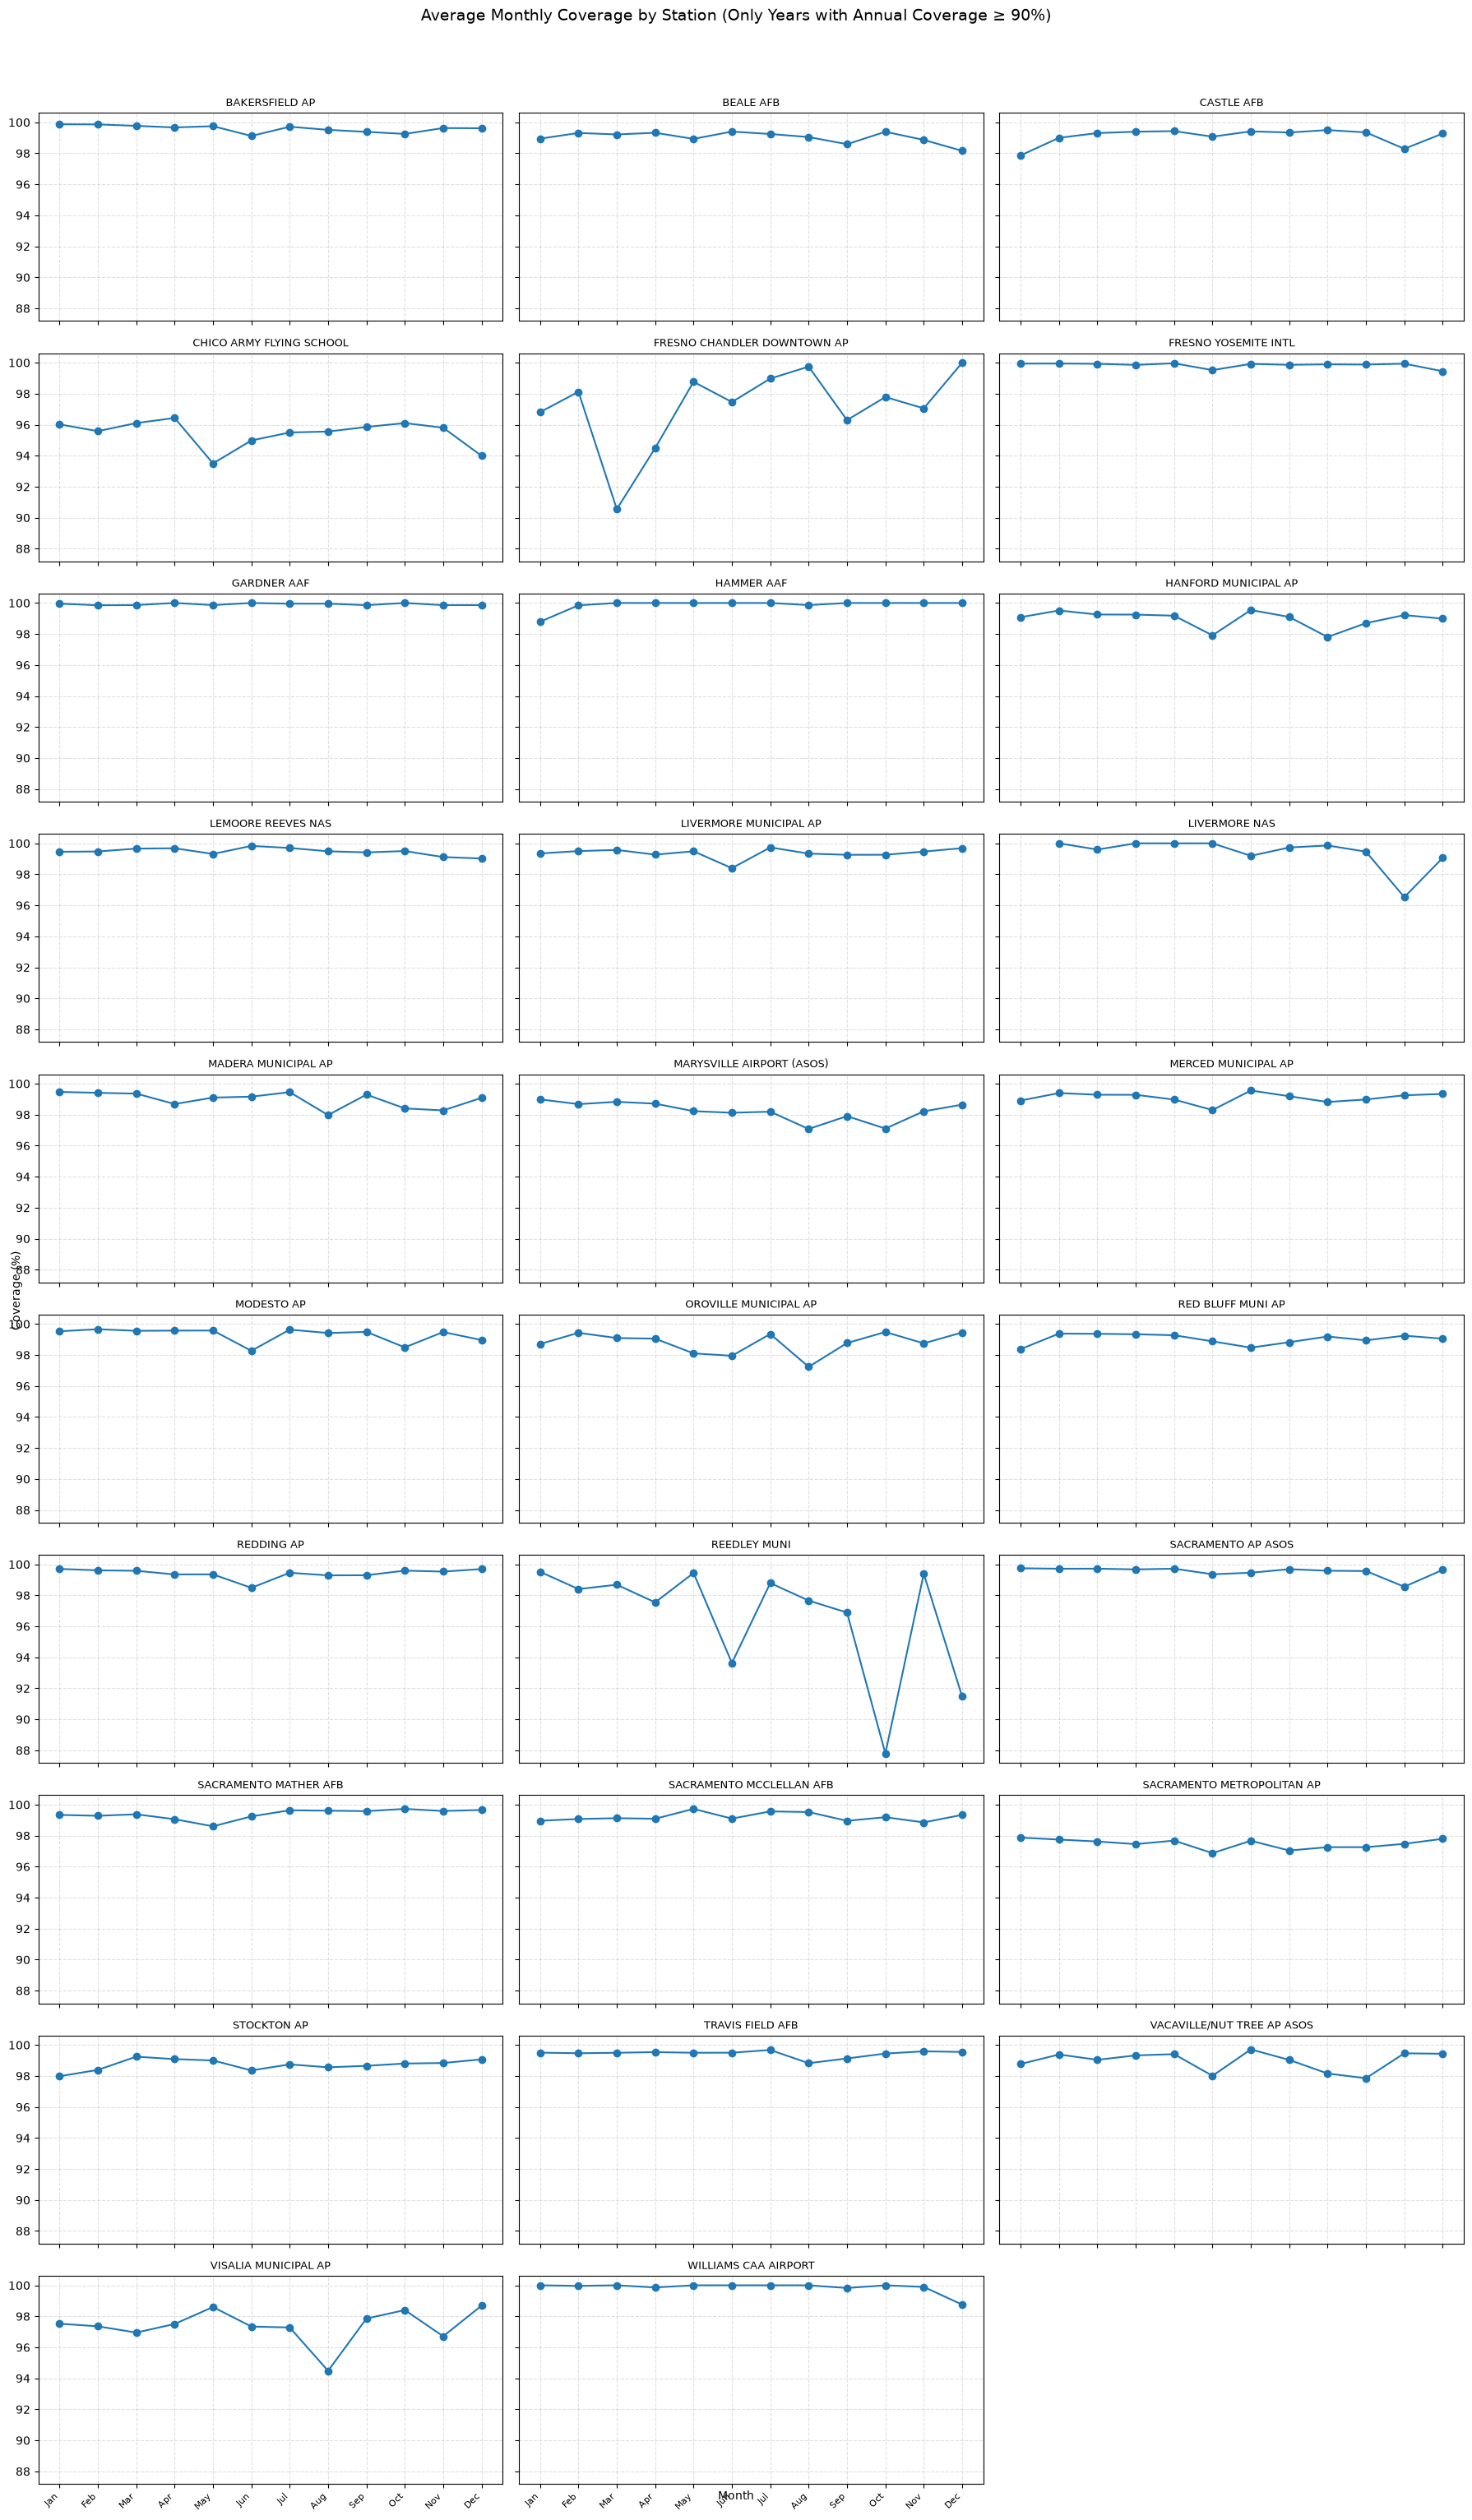

In [17]:
# Keep only station-year combinations with >=90% annual coverage
eligible_station_years = station_year_cov90[["STATION", "year"]].drop_duplicates()

# Monthly coverage restricted to eligible years
monthly_cov_90yr = monthly_coverage.merge(
    eligible_station_years,
    on=["STATION", "year"],
    how="inner"
)

# Average monthly coverage by station (across eligible years)
monthly_cov_90yr_summary = (
    monthly_cov_90yr
    .groupby(["STATION", "month"], as_index=False)["coverage_pct"]
    .mean()
    .sort_values(["STATION", "month"])
)

stations_plot = sorted(monthly_cov_90yr_summary["STATION"].unique())
n_stations = len(stations_plot)
ncols = 3
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for i, st in enumerate(stations_plot):
    ax = axes[i]
    st_df = monthly_cov_90yr_summary[monthly_cov_90yr_summary["STATION"] == st].set_index("month").reindex(range(1, 13))
    
    ax.plot(range(1, 13), st_df["coverage_pct"], marker="o", linewidth=1.5, color="tab:blue")
    ax.set_title(st, fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, rotation=45, ha="right", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Average Monthly Coverage by Station (Only Years with Annual Coverage ≥ 90%)", fontsize=14, y=1.02)
fig.text(0.5, 0.01, "Month", ha="center")
fig.text(0.01, 0.5, "Coverage (%)", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

In [18]:
# Keep only station-year periods with >=90% annual coverage from CV_rows
CV_rows_cov90 = CV_rows.merge(
    eligible_station_years,
    on=["STATION", "year"],
    how="inner"
)

print("Original CV_rows shape:", CV_rows.shape)
print("Filtered CV_rows_cov90 shape:", CV_rows_cov90.shape)
CV_rows_cov90.head()

Original CV_rows shape: (14495835, 17)
Filtered CV_rows_cov90 shape: (12582388, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,16.0,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,16.0,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,16.0,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,16.0,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,16.0,225.0,0.5,1941,12,1,4,0,GARDNER AAF


In [19]:
# save CV_rows_cov90 to CSV
# CV_rows_cov90.to_csv('CV_rows_cov90.csv', index=False)

In [20]:
# Keep only station-year periods with at least 90% data coverage
valid_months_90 = monthly_coverage.loc[
    monthly_coverage["coverage_pct"] >= 90, ["STATION", "year", "month"]
].drop_duplicates()

# Apply coverage filter to fog rows
CV_filtered_rows_cov90 = CV_filtered_rows.merge(
    valid_months_90,
    on=["STATION", "year", "month"],
    how="inner"
)

print("Original CV_filtered_rows shape:", CV_filtered_rows.shape)
print("Filtered CV_filtered_rows_cov90 shape:", CV_filtered_rows_cov90.shape)
CV_filtered_rows_cov90.head()

Original CV_filtered_rows shape: (10795959, 17)
Filtered CV_filtered_rows_cov90 shape: (10085454, 17)


,STATION_ID,LATITUDE,LONGITUDE,DATE,REPORT_TYPE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyPrecipitation,HourlyVisibility,HourlyWindDirection,HourlyWindSpeed,year,month,day,hour,minute,STATION
0,USM00074917,35.117,-119.3,1941-12-01 00:00:00,SAO,11.9,13.0,0.0,16.0,0.0,0.0,1941,12,1,0,0,GARDNER AAF
1,USM00074917,35.117,-119.3,1941-12-01 01:00:00,SAO,10.7,12.4,0.0,16.0,158.0,0.5,1941,12,1,1,0,GARDNER AAF
2,USM00074917,35.117,-119.3,1941-12-01 02:00:00,SAO,11.3,12.4,0.0,16.0,0.0,0.0,1941,12,1,2,0,GARDNER AAF
3,USM00074917,35.117,-119.3,1941-12-01 03:00:00,SAO,11.3,12.4,0.0,16.0,225.0,0.5,1941,12,1,3,0,GARDNER AAF
4,USM00074917,35.117,-119.3,1941-12-01 04:00:00,SAO,11.9,13.0,0.0,16.0,225.0,0.5,1941,12,1,4,0,GARDNER AAF


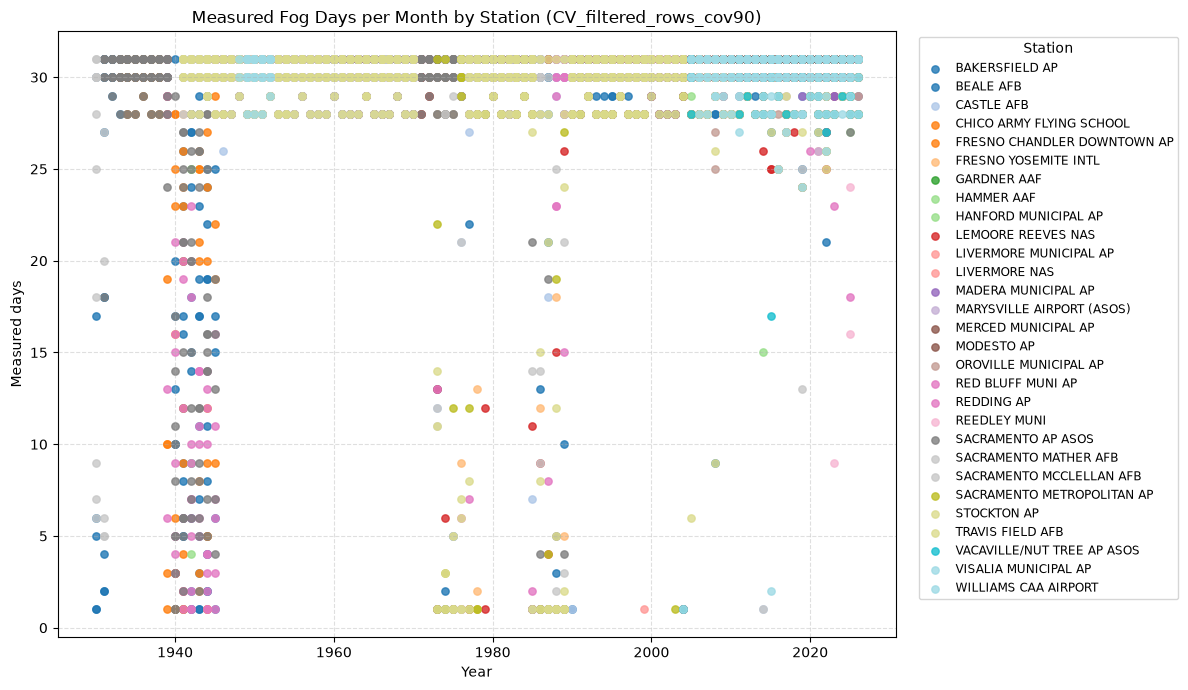

In [21]:
# Count measured fog days per station-year from CV_filtered_rows_cov90
measured_days_year_cov90 = (
    CV_filtered_rows_cov90
    .drop_duplicates(subset=["STATION", "year", "month", "day"])
    .groupby(["STATION", "year", "month"], as_index=False)
    .size()
    .rename(columns={"size": "measured_days"})
    .sort_values(["STATION", "year", "month"])
)

# Plot with one color per station
stations_cov90 = sorted(measured_days_year_cov90["STATION"].unique())
station_colors_cov90 = dict(zip(stations_cov90, plt.cm.tab20(np.linspace(0, 1, len(stations_cov90)))))

fig, ax = plt.subplots(figsize=(12, 7))

for st in stations_cov90:
    st_df = measured_days_year_cov90[measured_days_year_cov90["STATION"] == st]
    ax.scatter(
        st_df["year"],
        st_df["measured_days"],
        s=28,
        alpha=0.8,
        color=station_colors_cov90[st],
        label=st
    )

ax.set_title("Measured Fog Days per Month by Station (CV_filtered_rows_cov90)")
ax.set_xlabel("Year")
ax.set_ylabel("Measured days")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")
plt.tight_layout()
plt.show()

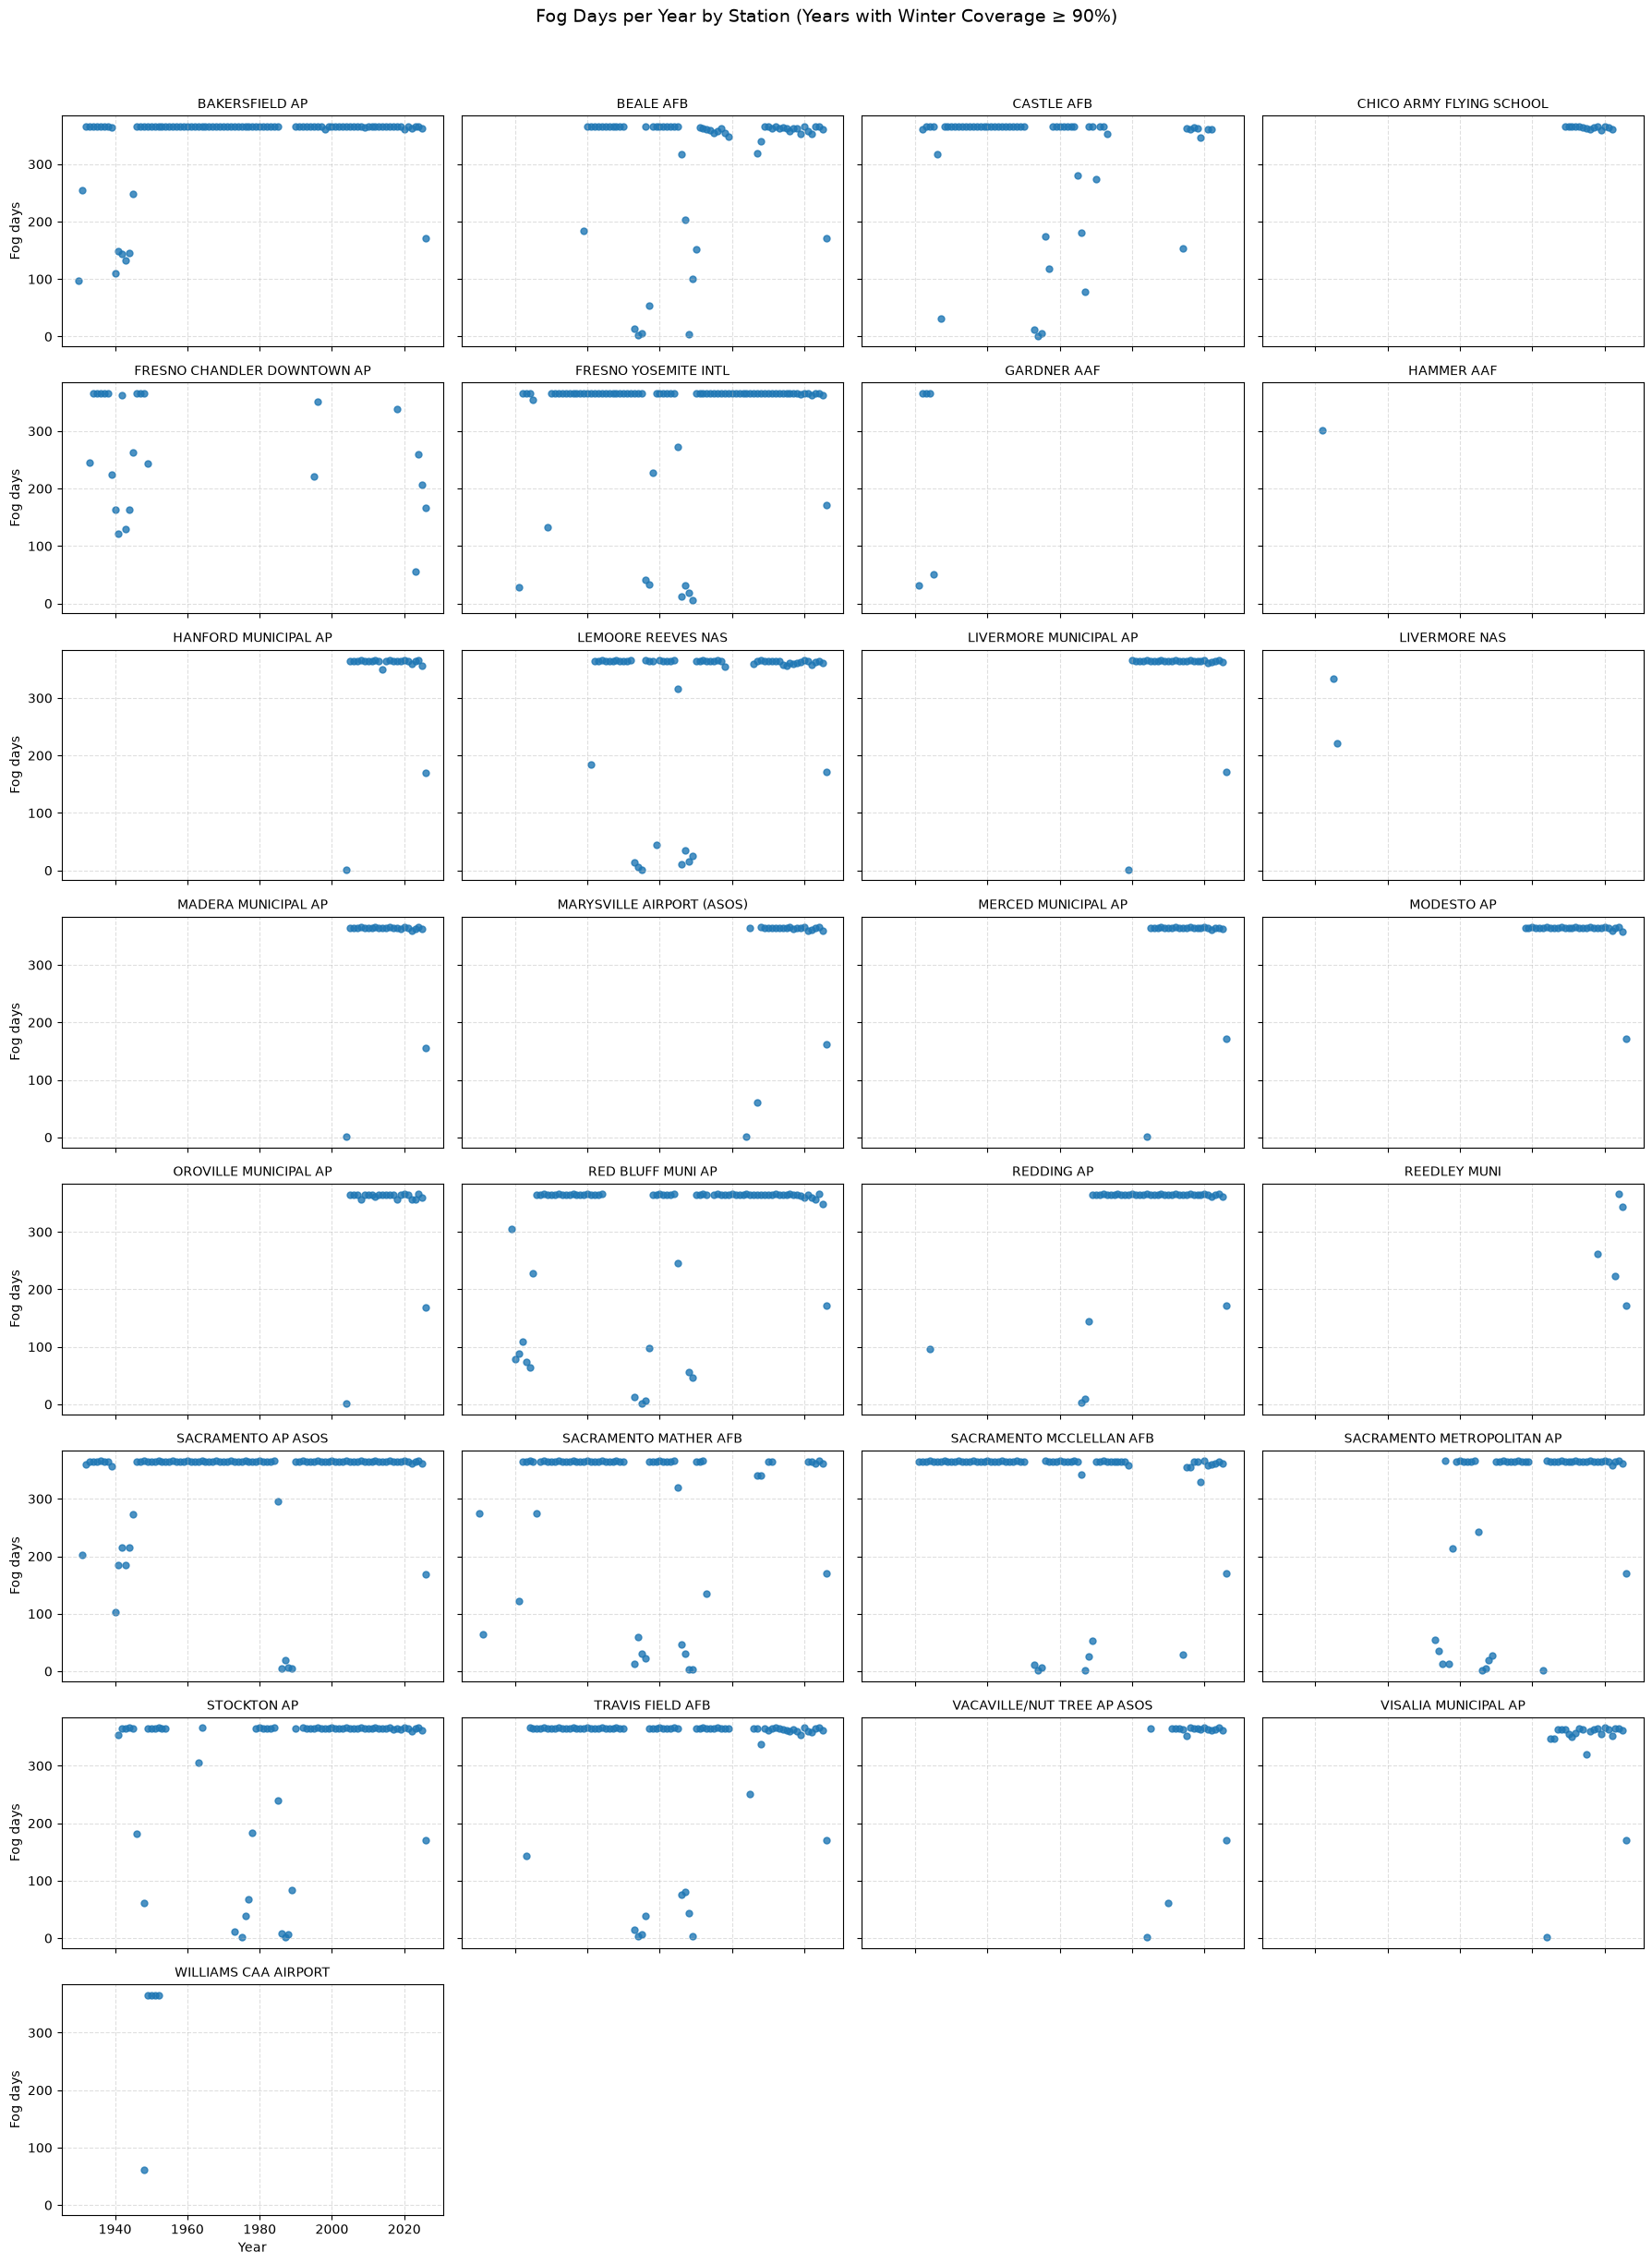

Stations included: 29
Total year-station combinations: 1163


In [22]:
# Create scatterplots for each station showing fog days per year
# Including years that have at least one winter month (Nov-Mar) with >= 90% coverage

# First, identify valid years per station based on winter month coverage
winter_months = [11, 12, 1, 2, 3]
valid_years_winter = (
    monthly_coverage[
        (monthly_coverage["month"].isin(winter_months)) & 
        (monthly_coverage["coverage_pct"] >= 90)
    ]
    .groupby(["STATION", "year"], as_index=False)
    .size()
    .drop(columns="size")
)

# Merge with fog_days_year to include only years with winter coverage
filtered_days_year_winter_cov = (
    filtered_days_year
    .merge(valid_years_winter, on=["STATION", "year"], how="inner")
    .sort_values(["STATION", "year"])
)

# Create scatterplots
stations = sorted(filtered_days_year_winter_cov["STATION"].unique())
n_stations = len(stations)
ncols = 4
nrows = int(np.ceil(n_stations / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3), sharex=True, sharey=True)
axes = axes.flatten()

for idx, station in enumerate(stations):
    ax = axes[idx]
    station_df = filtered_days_year_winter_cov[filtered_days_year_winter_cov["STATION"] == station].sort_values("year")
    
    ax.scatter(station_df["year"], station_df["filtered_days"], s=25, alpha=0.8, color="tab:blue")
    ax.set_title(station, fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    
    if idx % ncols == 0:
        ax.set_ylabel("Fog days")
    if idx >= (nrows - 1) * ncols:
        ax.set_xlabel("Year")

for ax in axes[n_stations:]:
    fig.delaxes(ax)

fig.suptitle("Fog Days per Year by Station (Years with Winter Coverage ≥ 90%)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Stations included: {len(stations)}")
print(f"Total year-station combinations: {len(filtered_days_year_winter_cov)}")